In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install imbalanced-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 5.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler
from sklearn.model_selection import train_test_split
import joblib
import pickle
from sklearn.preprocessing import MinMaxScaler



from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (precision_recall_curve, classification_report,
                           ConfusionMatrixDisplay, balanced_accuracy_score,roc_curve,
                           PrecisionRecallDisplay, confusion_matrix,roc_auc_score,RocCurveDisplay)



import warnings
warnings.filterwarnings('ignore')

In [4]:
data = pd.read_csv('/content/drive/MyDrive/data_cleaned.csv') #drive dev


In [ ]:
data.shape

(48700314, 16)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48700314 entries, 0 to 48700313
Data columns (total 16 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Source Port                  int64  
 1   Destination Port             int64  
 2   Flow Duration                int64  
 3   Total Fwd Packets            int64  
 4   Total Length of Fwd Packets  float64
 5   Fwd Packet Length Max        float64
 6   Flow IAT Mean                float64
 7   Flow IAT Std                 float64
 8   Flow IAT Max                 float64
 9   Flow IAT Min                 float64
 10  Fwd IAT Mean                 float64
 11  Fwd IAT Min                  float64
 12  Fwd Header Length            int64  
 13  Fwd Packets/s                float64
 14  min_seg_size_forward         int64  
 15  Label                        int64  
dtypes: float64(9), int64(7)
memory usage: 5.8 GB


In [ ]:
# Afficher les valeurs uniques et leur nombre
print(data["Label"].value_counts())

Label
1    48643451
0       56863
Name: count, dtype: int64


# Matrice de corrélation sur toutes les données

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul de la matrice de corrélation sur toutes les données
corr_matrix = data.corr()

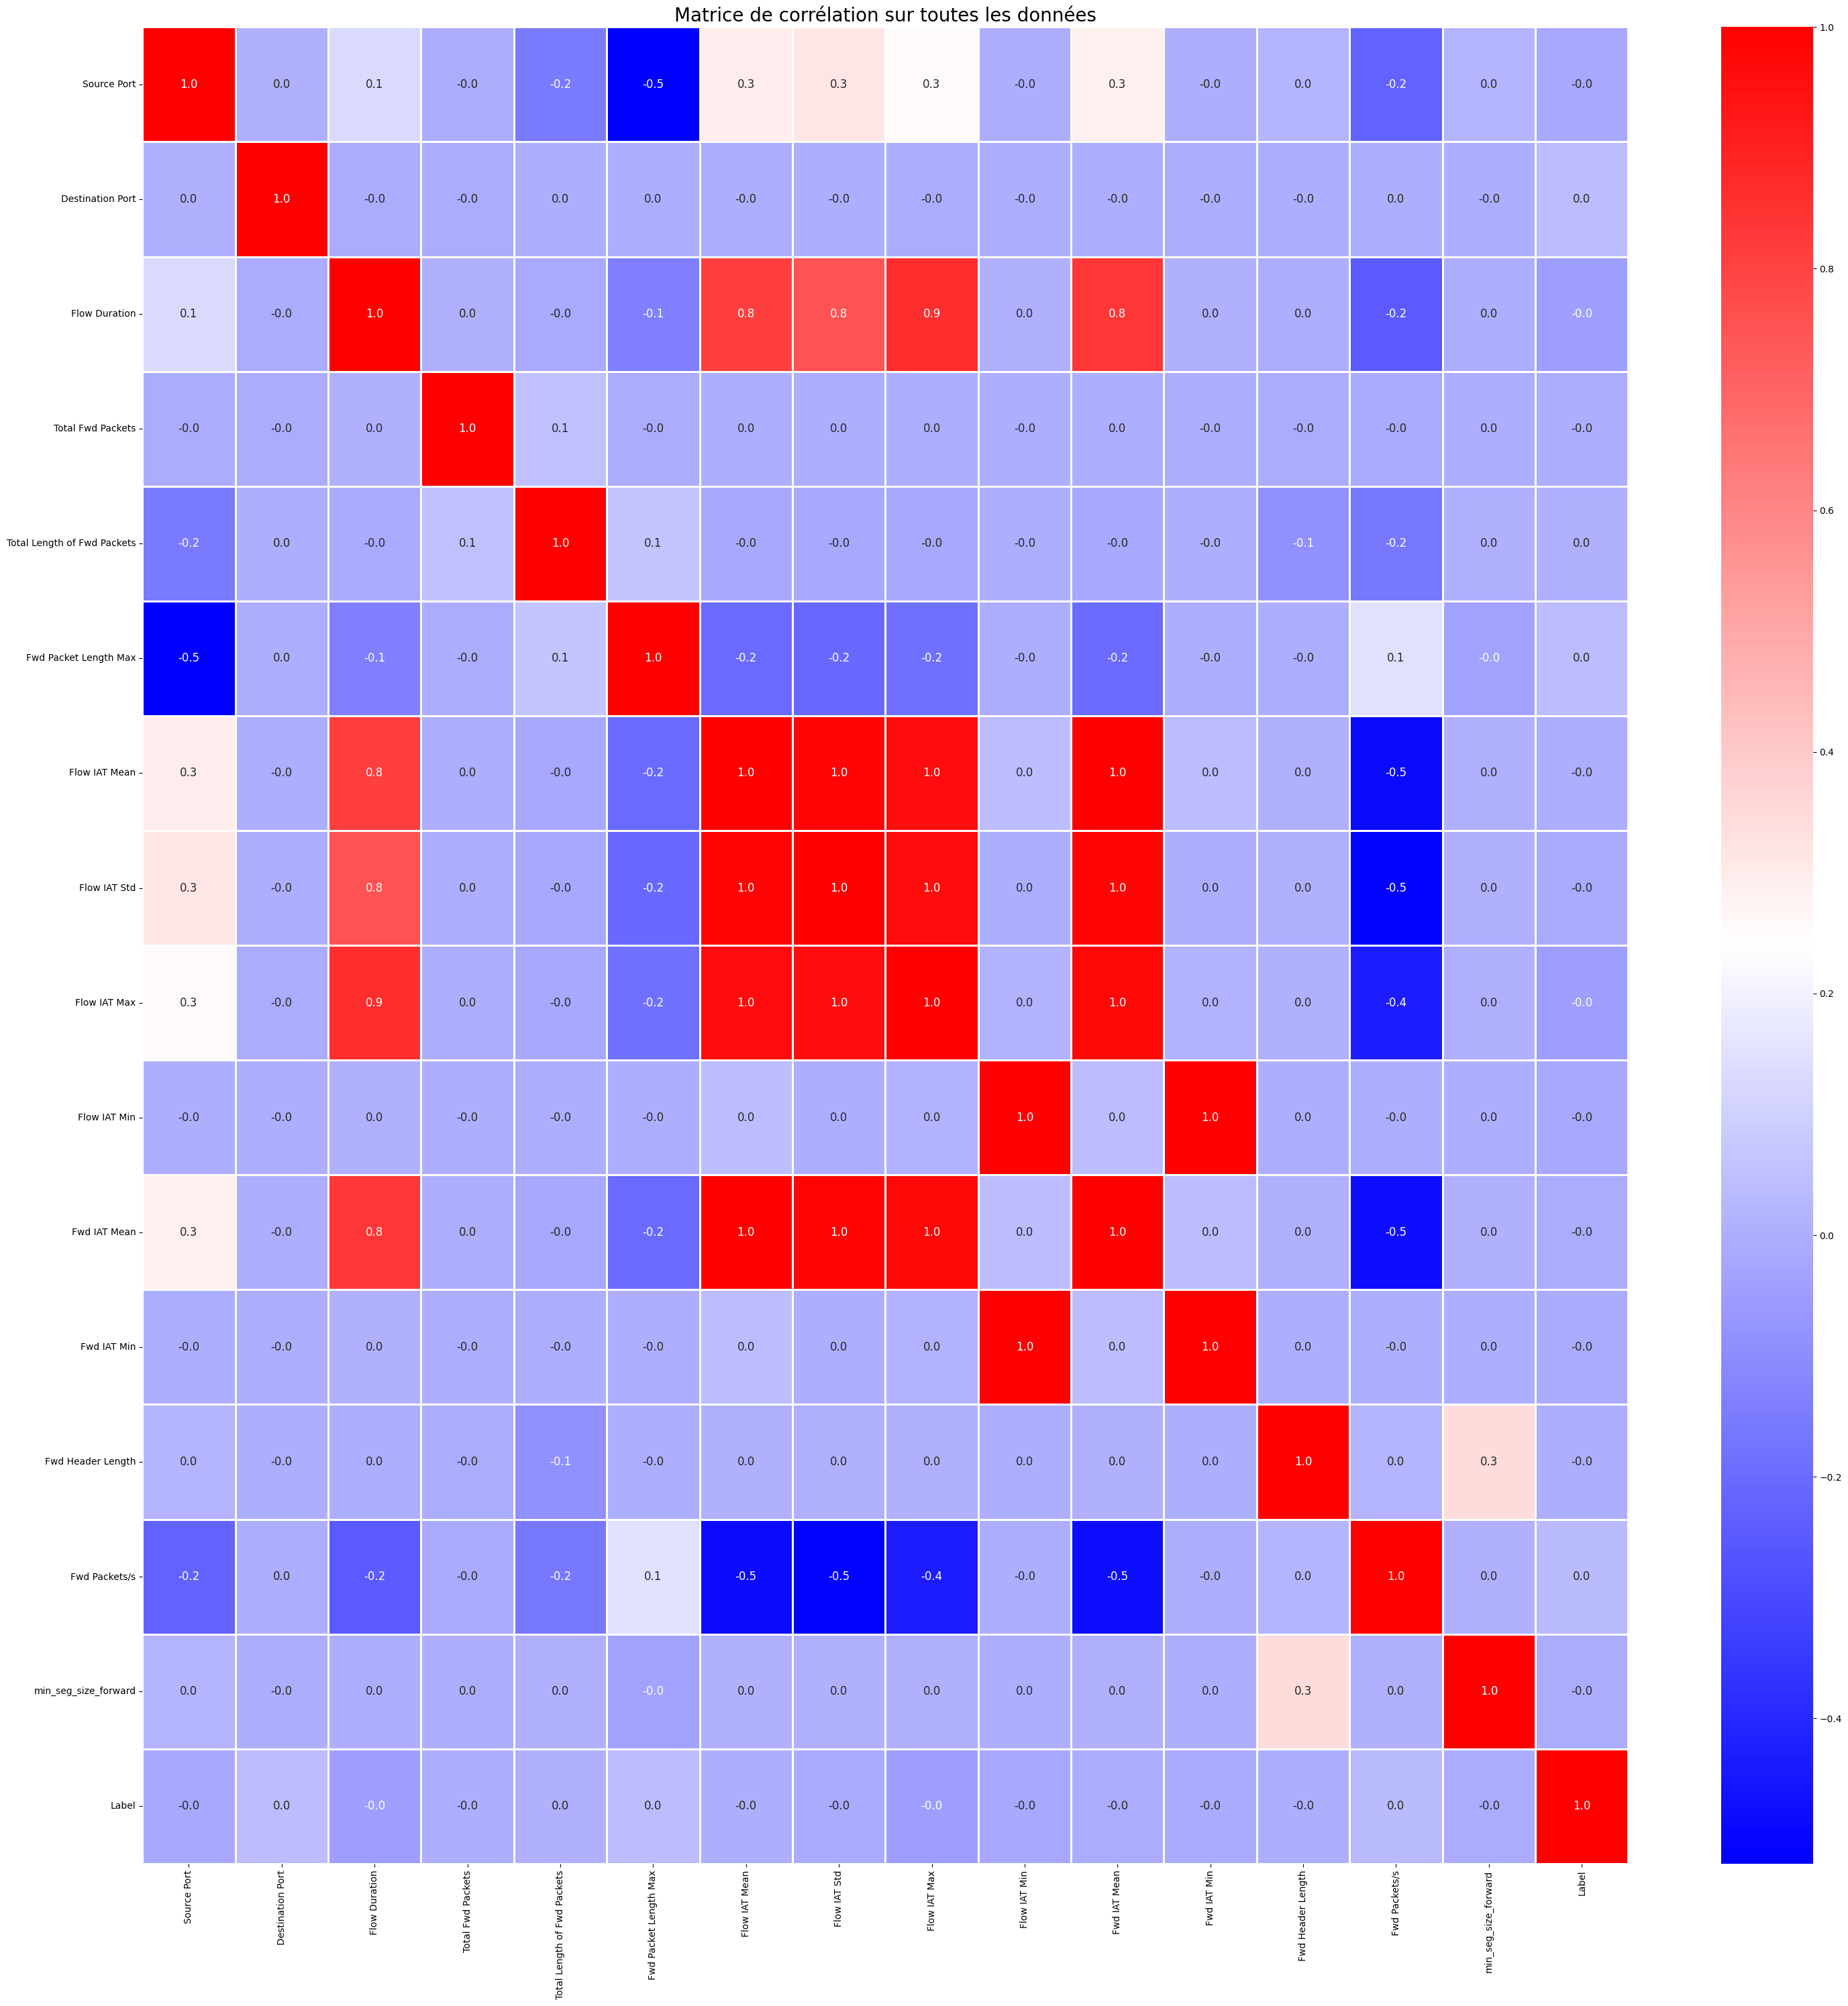

In [ ]:
# Affichage de la heatmap
plt.figure(figsize=(30, 30 ))  # Ajuste selon la densité souhaitée
sns.heatmap(corr_matrix, cmap='bwr', annot=True, fmt=".1f", linewidths=1,annot_kws={"size": 12} )
plt.title("Matrice de corrélation sur toutes les données", fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('heatmap_v3.png', dpi=300, bbox_inches='tight')
plt.show()

# Separation train test

In [5]:
# Séparation avec 70% train / 30% test
X = data.drop('Label', axis=1)
y = data['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,  # 30% pour le test
    random_state=42,  # Reproductibilité
    stratify=y  # Maintient la proportion Attack/BENIGN dans les deux sets
)


In [ ]:
print("Taille totale :", len(data))
print("Train set :", len(X_train), "| Test set :", len(X_test))
print("\nProportion 'BENIGN' (0) dans y_train :", y_train.mean())
print("Proportion 'BENIGN' (0) dans y_test :", y_test.mean())


Taille totale : 48700314
Train set : 34090219 | Test set : 14610095

Proportion 'BENIGN' (0) dans y_train : 0.9988323923645078
Proportion 'BENIGN' (0) dans y_test : 0.9988323826778676


In [ ]:
print("\nDistribution des labels dans y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribution des labels dans y_test:")
print(y_test.value_counts(normalize=True))


Distribution des labels dans y_train:
Label
1    0.998832
0    0.001168
Name: proportion, dtype: float64

Distribution des labels dans y_test:
Label
1    0.998832
0    0.001168
Name: proportion, dtype: float64


In [ ]:
X_train.info()
X_test.info()
y_train.info()
y_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34090219 entries, 16135442 to 36912278
Data columns (total 15 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Source Port                  int64  
 1   Destination Port             int64  
 2   Flow Duration                int64  
 3   Total Fwd Packets            int64  
 4   Total Length of Fwd Packets  float64
 5   Fwd Packet Length Max        float64
 6   Flow IAT Mean                float64
 7   Flow IAT Std                 float64
 8   Flow IAT Max                 float64
 9   Flow IAT Min                 float64
 10  Fwd IAT Mean                 float64
 11  Fwd IAT Min                  float64
 12  Fwd Header Length            int64  
 13  Fwd Packets/s                float64
 14  min_seg_size_forward         int64  
dtypes: float64(9), int64(6)
memory usage: 4.1 GB
<class 'pandas.core.frame.DataFrame'>
Index: 14610095 entries, 39364753 to 10109751
Data columns (total 15 columns):
 #

# Feature scaling

In [ ]:
# Comparaison des max entre train et test
print("Max (Train):", X_train.max())
print("Max (Test):", X_test.max())

Max (Train): Source Port                    6.553400e+04
Destination Port               6.553500e+04
Flow Duration                  1.200000e+08
Total Fwd Packets              1.001480e+05
Total Length of Fwd Packets    1.526642e+07
Fwd Packet Length Max          3.212000e+04
Flow IAT Mean                  6.553614e+07
Flow IAT Std                   6.736895e+07
Flow IAT Max                   1.199544e+08
Flow IAT Min                   6.553614e+07
Fwd IAT Mean                   6.553614e+07
Fwd IAT Min                    6.553614e+07
Fwd Header Length              1.559380e+05
Fwd Packets/s                  4.000000e+06
min_seg_size_forward           1.480000e+03
dtype: float64
Max (Test): Source Port                    6.553200e+04
Destination Port               6.553500e+04
Flow Duration                  1.200000e+08
Total Fwd Packets              9.997800e+04
Total Length of Fwd Packets    1.054386e+07
Fwd Packet Length Max          2.482000e+04
Flow IAT Mean                  5.119

In [ ]:
# Colonnes où le test dépasse le train
test_higher = X_test.max() > X_train.max()
print("Colonnes avec max(test) > max(train):\n", test_higher[test_higher].index.tolist())

Colonnes avec max(test) > max(train):
 ['Flow IAT Std']


In [6]:
# Colonnes problématiques
problem_cols = ['Flow IAT Std']

# 1. Calculer les min/max globaux (train + test)
global_min = np.minimum(X_train.min(), X_test.min())
global_max = np.maximum(X_train.max(), X_test.max())

# 2. Initialiser le MinMaxScaler avec ces valeurs
scaler = MinMaxScaler()
scaler.fit(X_train)  # Initialisation standard

# 3. Forcer les min/max globaux pour les colonnes problématiques
scaler.data_min_[X_train.columns.get_indexer(problem_cols)] = global_min[problem_cols].values
scaler.data_max_[X_train.columns.get_indexer(problem_cols)] = global_max[problem_cols].values

# 4. Normalisation
X_train_normalized = scaler.transform(X_train)
X_test_normalized = scaler.transform(X_test)

In [7]:
# Correction finale (au cas où)
X_test_normalized = np.clip(X_test_normalized, 0.0, 1.0)

# Vérification
print("Test - Valeurs > 1.0 :", np.any(X_test_normalized > 1.0))  # Doit être False
print("Max globaux utilisés :", scaler.data_max_[X_train.columns.get_indexer(problem_cols)])

Test - Valeurs > 1.0 : False
Max globaux utilisés : [68082925.44583908]


In [ ]:
print("Train - Statistiques après normalisation:")
print(pd.DataFrame(X_train_normalized, columns=X_train.columns).describe())
print("\nTest - Statistiques après normalisation:")
print(pd.DataFrame(X_test_normalized, columns=X_test.columns).describe())

Train - Statistiques après normalisation:
        Source Port  Destination Port  Flow Duration  Total Fwd Packets  \
count  3.409022e+07      3.409022e+07   3.409022e+07       3.409022e+07   
mean   4.968842e-01      5.010200e-01   9.631982e-03       4.087742e-05   
std    4.194827e-01      2.884934e-01   4.655156e-02       2.518893e-03   
min    0.000000e+00      0.000000e+00   0.000000e+00       0.000000e+00   
25%    1.283303e-02      2.516365e-01   8.333333e-09       9.985322e-06   
50%    5.818659e-01      5.011673e-01   1.666667e-08       9.985322e-06   
75%    9.533677e-01      7.510185e-01   9.078833e-04       2.995596e-05   
max    1.000000e+00      1.000000e+00   1.000000e+00       1.000000e+00   

       Total Length of Fwd Packets  Fwd Packet Length Max  Flow IAT Mean  \
count                 3.409022e+07           3.409022e+07   3.409022e+07   
mean                  1.593178e-04           2.128862e-02   3.889313e-03   
std                   4.424665e-04           1.420118e

In [ ]:
from joblib import dump
# 3. Sauvegarder le scaler dans Drive
scaler_path = 'v3_scaler_final.pkl'  # Chemin personnalisable
dump(scaler, scaler_path)

print(f"✅ Scaler sauvegardé ici : {scaler_path}")

✅ Scaler sauvegardé ici : v3_scaler_final.pkl


# Sampling avec ADASYN

In [8]:
from imblearn.over_sampling import ADASYN

# Appliquer ADASYN pour oversampler la classe 0
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_normalized, y_train)

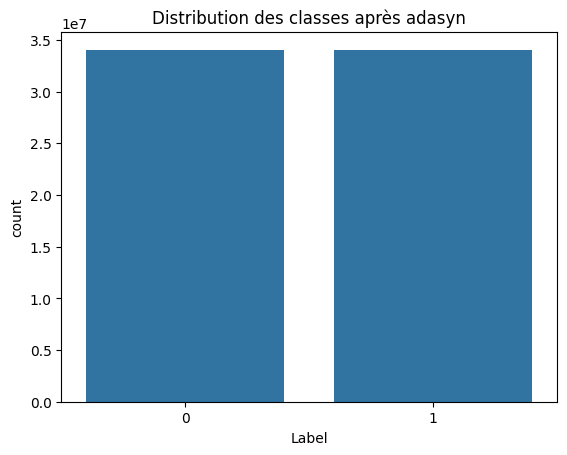

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution après ADASYN
sns.countplot(x=y_train_adasyn)
plt.title("Distribution des classes après adasyn")
plt.show()

In [ ]:
# Avant ADASYN
print("Distribution avant adasyn :")
print(y_train.value_counts())

# Après ADASYN
print("\nDistribution après adasyn :")
print(pd.Series(y_train_adasyn).value_counts())

Distribution avant adasyn :
Label
1    34050415
0       39804
Name: count, dtype: int64

Distribution après adasyn :
Label
0    34050729
1    34050415
Name: count, dtype: int64


In [ ]:
X_train_adasyn.shape

(68101144, 15)

In [ ]:
y_train_adasyn.shape

(68101144,)

# Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import time

In [ ]:
# 1. Initialisation du modèle avec des paramètres optimisés pour vitesse/performance
model = RandomForestClassifier(
                               n_estimators=100,
                               random_state=42,
                               verbose=1,
                               n_jobs=-1

)

In [ ]:
start_train = time.time()
model.fit(X_train_adasyn, y_train_adasyn)
end_train = time.time()

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed: 35.4min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 92.1min finished


In [ ]:
import joblib
# Sauvegarde du modèle dans un fichier .pkl
joblib.dump(model, 'modelv3_rf_adasyn.pkl')


['modelv3_rf_adasyn.pkl']

In [ ]:
import zipfile
# 3. Créer un fichier ZIP et y ajouter le .pkl
zip_filename = 'v3_RF_model_new.zip'
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write('modelv3_rf_adasyn.pkl')
print(f"Modèle sauvegardé et compressé avec succès dans : {zip_filename}")

In [ ]:
# Supposons que X_train était un DataFrame avant ADASYN
feature_names = X_train.columns.tolist()
# Maintenant tu veux récupérer les colonnes : convertis l'array numpy en DataFrame
X_train_adasyn_df = pd.DataFrame(X_train_adasyn, columns=feature_names)

# Tu peux alors faire :
print(X_train_adasyn_df.columns.tolist())

['Source Port', 'Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Mean', 'Fwd IAT Min', 'Fwd Header Length', 'Fwd Packets/s', 'min_seg_size_forward']


In [ ]:
# Prédiction avec mesure du temps
start_pred = time.time()
y_pred = model.predict(X_test_normalized)
y_pred_prob = model.predict_proba(X_test_normalized)[:, 1]
end_pred = time.time()


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    6.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:   17.6s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    6.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:   17.5s finished


In [ ]:
# Création initiale du fichier avec un en-tête
with open("resultats_analyse_rf.txt", "w", encoding="utf-8") as f:
    f.write("═"*60 + "\n")
    f.write("           RAPPORT D'ÉVALUATION DU MODÈLE DE DÉTECTION           \n")
    f.write("═"*60 + "\n\n")

In [ ]:
# Évaluer
report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)
# Affichage
print("Classification Report :\n", report)
print("Confusion Matrix :\n", matrix)

# Sauvegarde dans le fichier texte sans écrasement
with open("resultats_analyse_rf.txt", "a", encoding="utf-8") as f:
    f.write("=== RAPPORT DE CLASSIFICATION ===\n")
    f.write(report + "\n")
    f.write("=== MATRICE DE CONFUSION ===\n")
    f.write(np.array2string(matrix, separator=' ') + "\n\n")

Classification Report :
               precision    recall  f1-score   support

           0       0.96      1.00      0.98     17059
           1       1.00      1.00      1.00  14593036

    accuracy                           1.00  14610095
   macro avg       0.98      1.00      0.99  14610095
weighted avg       1.00      1.00      1.00  14610095

Confusion Matrix :
 [[   17038       21]
 [     735 14592301]]


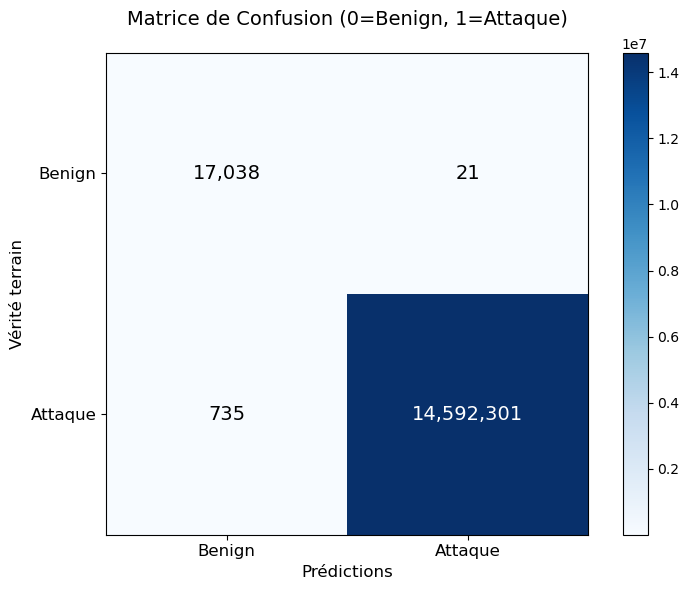

In [ ]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
# Création d'une visualisation claire
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matrice de Confusion (0=Benign, 1=Attaque)', fontsize=14, pad=20)
plt.colorbar()

# Configuration des axes
class_names = ['Benign', 'Attaque']
plt.xticks([0, 1], class_names, fontsize=12)
plt.yticks([0, 1], class_names, fontsize=12)
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Vérité terrain', fontsize=12)

# Ajout des valeurs annotées
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i, j]:,}",  # Format avec séparateurs de milliers
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=14)

# Affichage et sauvegarde
plt.tight_layout()
plt.savefig('matrice_confusion_RF.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Calcul du FPR à partir de la matrice de confusion
TN, FP, FN, TP = cm.ravel()  # Récupère les valeurs de la matrice de confusion

FPR = FP / (FP + TN)  # Taux de faux positifs (FPR)
print(f""" - Taux de Faux Positifs (FPR) : {FPR:.4f}""")

FNR = FN / (FN + TP)
print(f""" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}
""")

 - Taux de Faux Positifs (FPR) : 0.0012
 - Taux de Faux Négatifs (Attaques manquées) FNR: 0.0001



In [ ]:
# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse_rf.txt", "a", encoding="utf-8") as f:
    f.write(f" - Taux de Faux Positifs (FPR) : {FPR:.4f}\n")
    f.write(f" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}\n\n")

In [ ]:
# 8. Temps de prédiction et d'entrainement
print(f"Temps de prédiction : {end_pred - start_pred:.2f} secondes")
print(f"Temps d'entrainement : {end_train - start_train:.2f} secondes")


Temps de prédiction : 43.44 secondes
Temps d'entrainement : 5537.77 secondes


In [ ]:
temps_prediction = end_pred - start_pred
temps_train = end_train - start_train
# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse_rf.txt", "a", encoding="utf-8") as f:
    f.write(f"Temps de prédiction : {temps_prediction:.2f} secondes\n\n")
    f.write(f"Temps d'entrainement  : {temps_train:.2f} secondes\n\n")

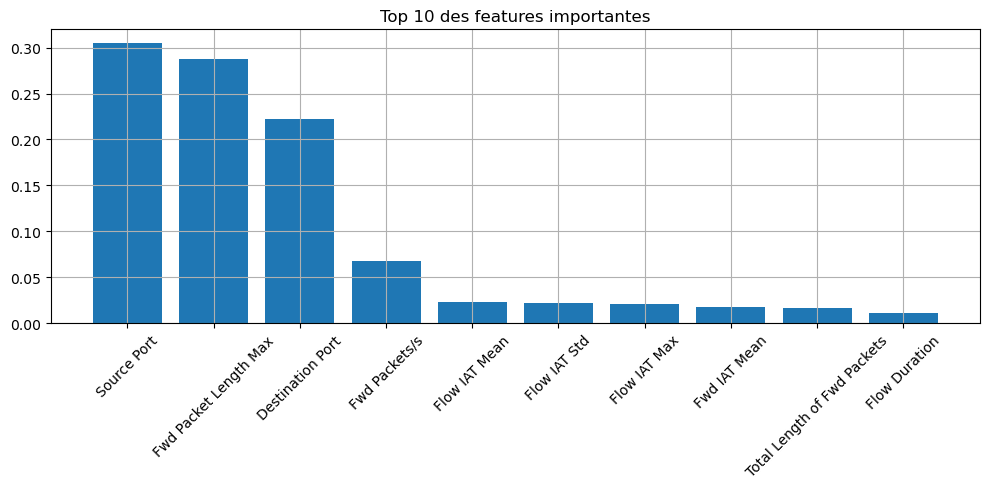

In [ ]:
# 10. Feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[-10:][::-1]  # top 10
features = X_test.columns[indices]

plt.figure(figsize=(10, 5))
plt.title("Top 10 des features importantes")
plt.bar(range(len(indices)), importances[indices], align="center")
plt.xticks(range(len(indices)), features, rotation=45)
plt.tight_layout()
plt.grid(True)
plt.savefig("feature_importance.png")
plt.show()


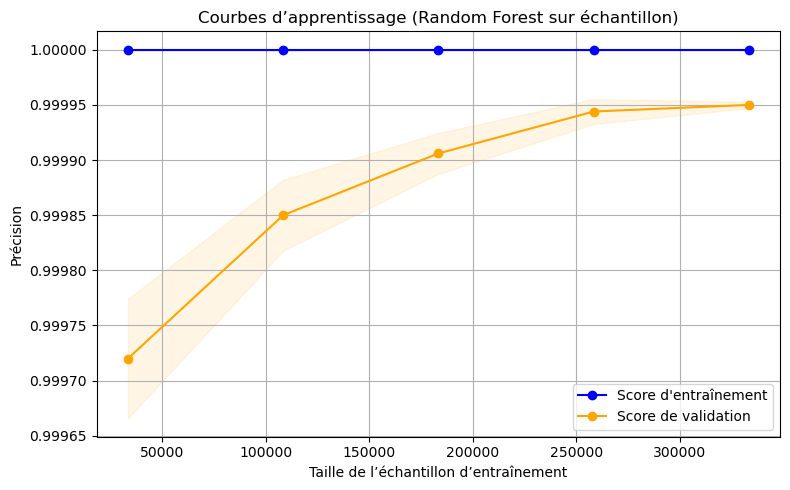

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_test, y_test, n_samples=500000, random_state=42)

# Génération des courbes d’apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    model, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d’apprentissage (Random Forest sur échantillon)")
plt.xlabel("Taille de l’échantillon d’entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve.png")
plt.show()


In [9]:
import joblib
modelrf = joblib.load('modelv3_rf_adasyn.pkl')
print(type(modelrf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


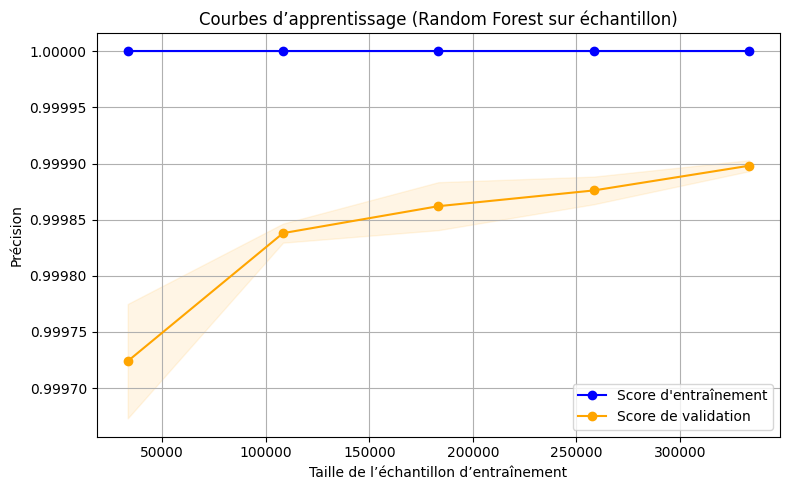

In [10]:

from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_train_adasyn, y_train_adasyn, n_samples=500000, random_state=42)

# Génération des courbes d’apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    modelrf, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d’apprentissage (Random Forest sur échantillon)")
plt.xlabel("Taille de l’échantillon d’entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_train_rf_v3.png")
plt.show()


# Random forest n_estimators=8

In [21]:
import joblib
modelrf = joblib.load('modelv3_random_forest_new.pkl')
print(type(modelrf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


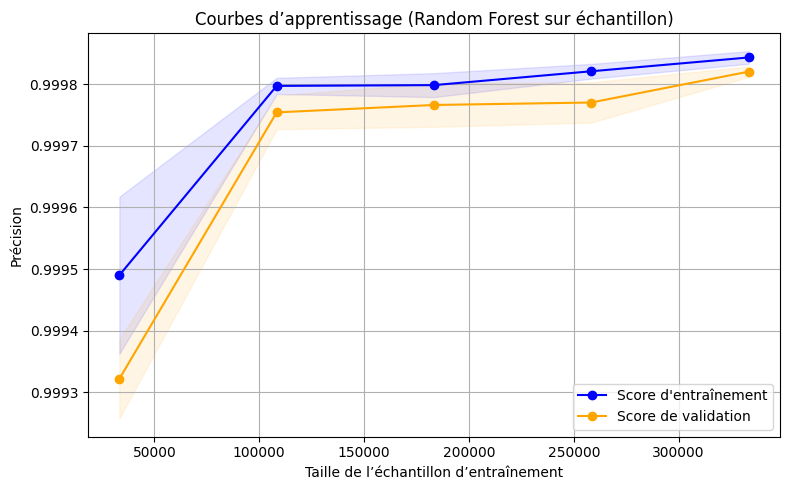

In [22]:

from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_train_adasyn, y_train_adasyn, n_samples=500000, random_state=42)

# Génération des courbes d’apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    modelrf, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d’apprentissage (Random Forest sur échantillon)")
plt.xlabel("Taille de l’échantillon d’entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_train_rf8_v3.png")
plt.show()


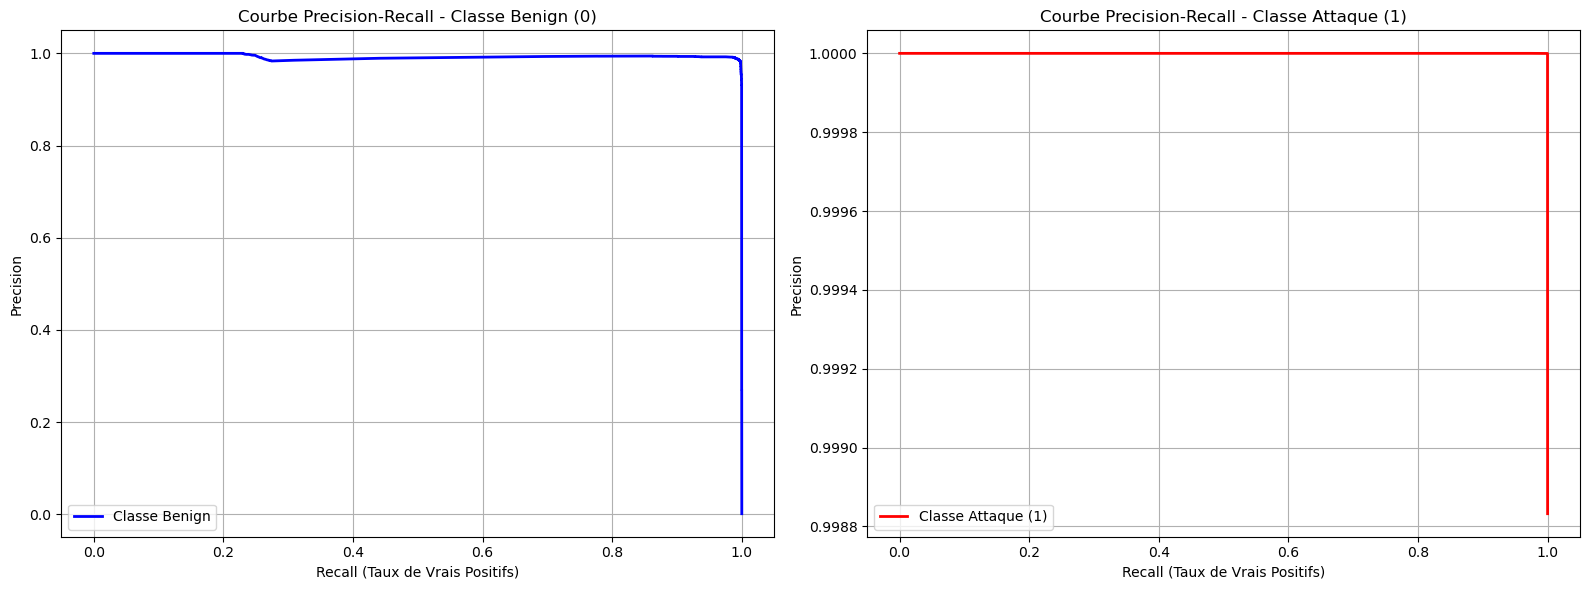

In [ ]:
# Configuration globale
plt.figure(figsize=(16, 6))

# =============================================
# 1. Subplot GAUCHE - Classe Benign (version libre)
# =============================================
plt.subplot(1, 2, 1)
precision_benign, recall_benign, _ = precision_recall_curve(y_test, 1 - y_pred_prob, pos_label=0)
plt.plot(recall_benign, precision_benign, color='blue', lw=2, label='Classe Benign')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - Classe Benign (0)')
plt.legend()
plt.grid()
# Suppression des limites forcées
plt.autoscale(enable=True, axis='both', tight=False)

# =============================================
# 2. Subplot DROITE - Classe Attaque (version libre)
# =============================================
plt.subplot(1, 2, 2)
precision_attack, recall_attack, _ = precision_recall_curve(y_test, y_pred_prob, pos_label=1)
plt.plot(recall_attack, precision_attack, color='red', lw=2, label='Classe Attaque (1)')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - Classe Attaque (1)')
plt.legend()
plt.grid()
# Suppression des limites forcées
plt.autoscale(enable=True, axis='both', tight=False)

# Ajustement automatique
plt.tight_layout()
plt.savefig("courbes-precision-recall-0-1.png")
plt.show()

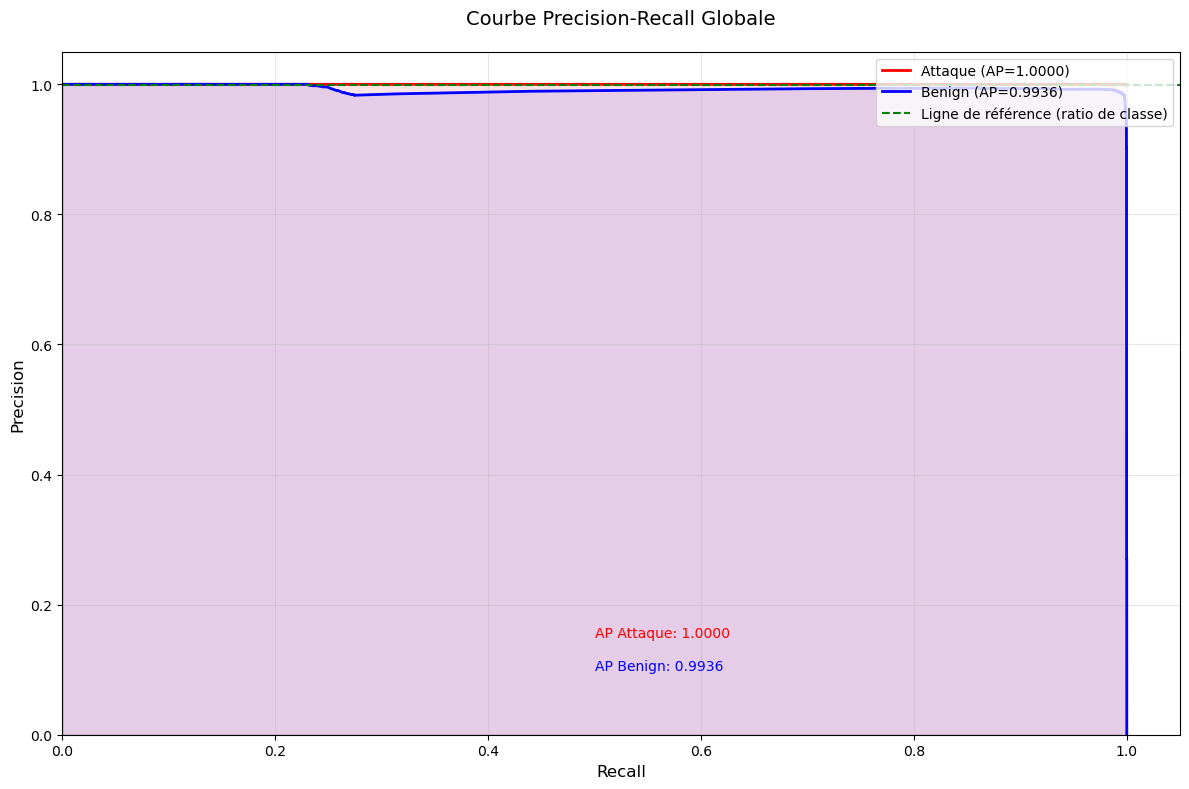

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
# 1. Calcul pour les deux classes
precision_attack, recall_attack, _ = precision_recall_curve(y_test, y_pred_prob, pos_label=1)
precision_benign, recall_benign, _ = precision_recall_curve(y_test, 1 - y_pred_prob, pos_label=0)

# 2. Calcul des Average Precision (AP)
ap_attack = average_precision_score(y_test, y_pred_prob, pos_label=1)
ap_benign = average_precision_score(y_test, 1 - y_pred_prob, pos_label=0)

# 3. Tracé global
plt.figure(figsize=(12, 8))
plt.plot(recall_attack, precision_attack, color='red', lw=2,
         label=f'Attaque (AP={ap_attack:.4f})', linestyle='-')
plt.plot(recall_benign, precision_benign, color='blue', lw=2,
         label=f'Benign (AP={ap_benign:.4f})', linestyle='-')

# Ligne de référence
plt.axhline(y=len(y_test[y_test==1])/len(y_test), color='green', linestyle='--',
            label='Ligne de référence (ratio de classe)')

# Mise en forme avancée
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Courbe Precision-Recall Globale', fontsize=14, pad=20)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])

# Annotations
plt.text(0.5, 0.15, f"AP Attaque: {ap_attack:.4f}", color='red', fontsize=10)
plt.text(0.5, 0.10, f"AP Benign: {ap_benign:.4f}", color='blue', fontsize=10)

# Ajout des aires sous courbe
plt.fill_between(recall_attack, precision_attack, color='red', alpha=0.1)
plt.fill_between(recall_benign, precision_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-precision-recall-global.png")
plt.show()

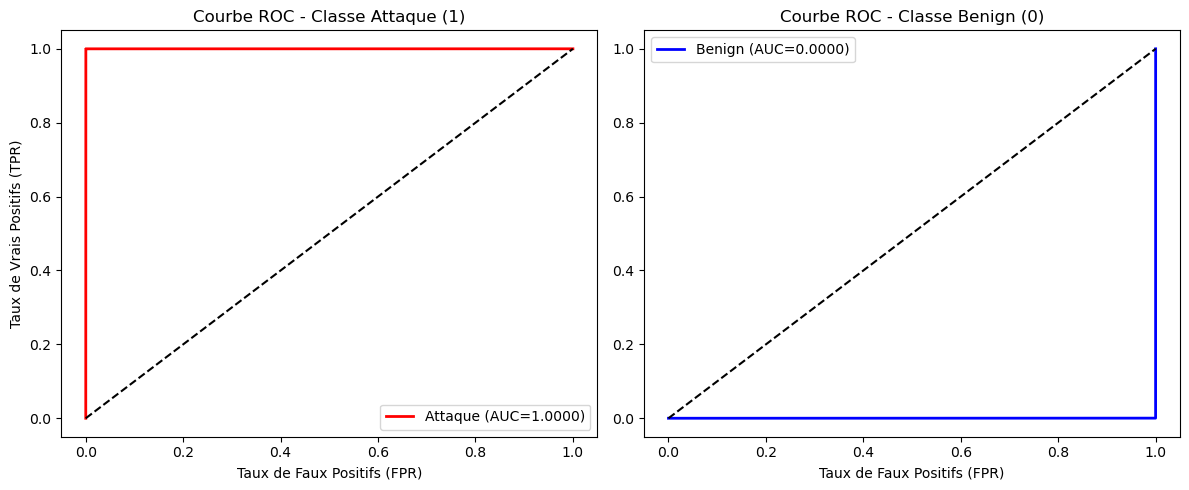

In [ ]:
# 1. Courbe ROC - Classe Attaque (pos_label=1)
fpr_attack, tpr_attack, _ = roc_curve(y_test, y_pred_prob, pos_label=1)
auc_attack = roc_auc_score(y_test, y_pred_prob)  # Pas de pos_label ici

# 2. Courbe ROC - Classe Benign (pos_label=0)
fpr_benign, tpr_benign, _ = roc_curve(y_test, y_pred_prob, pos_label=0)
auc_benign = roc_auc_score(y_test, 1 - y_pred_prob)  # Inversion des probabilités

# Tracé
plt.figure(figsize=(12, 5))

# Subplot gauche - Attaque
plt.subplot(1, 2, 1)
plt.plot(fpr_attack, tpr_attack, color='red', lw=2, label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC - Classe Attaque (1)')
plt.legend()

# Subplot droit - Benign
plt.subplot(1, 2, 2)
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2, label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.title('Courbe ROC - Classe Benign (0)')
plt.legend()

plt.tight_layout()
plt.savefig("courbes-ROC-0-1.png")
plt.show()

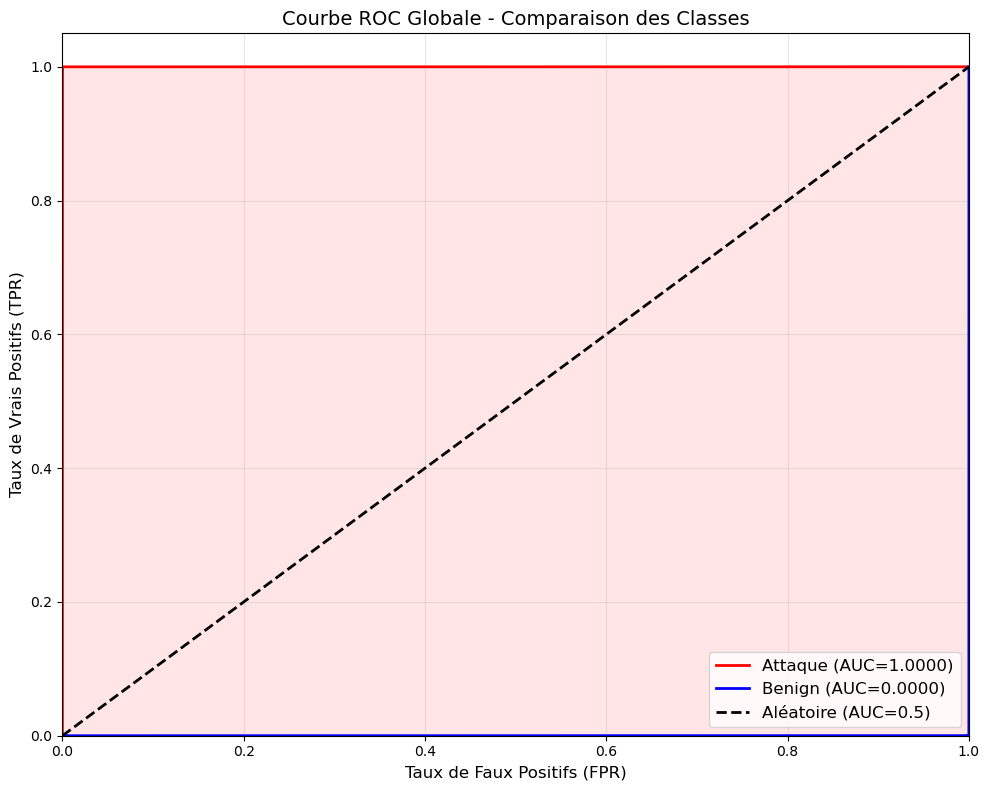

In [ ]:
# 1. Calcul pour la classe Attaque (1)
fpr_attack, tpr_attack, _ = roc_curve(y_test, y_pred_prob, pos_label=1)
auc_attack = roc_auc_score(y_test, y_pred_prob)

# 2. Calcul pour la classe Benign (0)
fpr_benign, tpr_benign, _ = roc_curve(y_test, y_pred_prob, pos_label=0)
auc_benign = roc_auc_score(y_test, 1 - y_pred_prob)

# 3. Tracé global
plt.figure(figsize=(10, 8))
plt.plot(fpr_attack, tpr_attack, color='red', lw=2,
         label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2,
         label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Aléatoire (AUC=0.5)')

# Mise en forme
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC Globale - Comparaison des Classes', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Ajout des zones critiques
plt.fill_between(fpr_attack, tpr_attack, color='red', alpha=0.1)
plt.fill_between(fpr_benign, tpr_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-ROC-globale.png")
plt.show()

In [ ]:
# Calcul des scores AUC-ROC
auc_attack = roc_auc_score(y_test, y_pred_prob)
auc_benign = roc_auc_score(y_test, 1 - y_pred_prob)
auc_global = (auc_attack + auc_benign) / 2  # Moyenne macro

# Affichage formaté
print("\n" + "═"*50)
print(" PERFORMANCE DU MODÈLE ".center(50, "~"))
print("═"*50)
print(f"\n\033[1m• AUC-ROC Classe Attaque (1)\033[0m : {auc_attack:.6f}")
print(f"\033[1m• AUC-ROC Classe Benign (0)\033[0m  : {auc_benign:.6f}")
print(f"\n\033[1m• AUC-ROC Global (macro)\033[0m     : {auc_global:.6f}")
print("\n" + "═"*50)


══════════════════════════════════════════════════
~~~~~~~~~~~~~ PERFORMANCE DU MODÈLE ~~~~~~~~~~~~~~
══════════════════════════════════════════════════

• AUC-ROC Classe Attaque (1) : 0.999994
• AUC-ROC Classe Benign (0)  : 0.000006

• AUC-ROC Global (macro)     : 0.500000

══════════════════════════════════════════════════


In [ ]:
# Sauvegarde dans le fichier texte sans écrasement
with open("resultats_analyse_rf.txt", "a", encoding="utf-8") as f:
    f.write("\n" + "═"*50 + "\n")
    f.write(" PERFORMANCE DU MODÈLE ".center(50, "~") + "\n")
    f.write("═"*50 + "\n")
    f.write(f"\n• AUC-ROC Classe Attaque (1) : {auc_attack:.6f}\n")
    f.write(f"• AUC-ROC Classe Benign (0)  : {auc_benign:.6f}\n")
    f.write(f"\n• AUC-ROC Global (macro)     : {auc_global:.6f}\n")
    f.write("═"*50 + "\n\n")

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np

# Calcul des métriques
metrics = {
    'Précision': {
        'Benign': precision_score(y_test, y_pred, pos_label=0),
        'Attaque': precision_score(y_test, y_pred, pos_label=1),
        'Global': precision_score(y_test, y_pred, average='macro')
    },
    'Recall': {
        'Benign': recall_score(y_test, y_pred, pos_label=0),
        'Attaque': recall_score(y_test, y_pred, pos_label=1),
        'Global': recall_score(y_test, y_pred, average='macro')
    },
    'F1-Score': {
        'Benign': f1_score(y_test, y_pred, pos_label=0),
        'Attaque': f1_score(y_test, y_pred, pos_label=1),
        'Global': f1_score(y_test, y_pred, average='macro')
    },
    'Accuracy': {
        'Global': accuracy_score(y_test, y_pred)
    }
}

# Affichage formaté
print("╔═════════════════════════════════════════════╗")
print("║          PERFORMANCE DU MODÈLE              ║")
print("╠══════════════╦══════════╦══════════╦════════╣")
print("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║")
print("╠══════════════╬══════════╬══════════╬════════╣")

for metric_name, values in metrics.items():
    if metric_name == 'Accuracy':
        print(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║")
    else:
        print(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║")

print("╚══════════════╩══════════╩══════════╩════════╝")
# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse_rf.txt", "a", encoding="utf-8") as f:
    f.write("╔═════════════════════════════════════════════╗\n")
    f.write("║          PERFORMANCE DU MODÈLE              ║\n")
    f.write("╠══════════════╦══════════╦══════════╦════════╣\n")
    f.write("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║\n")
    f.write("╠══════════════╬══════════╬══════════╬════════╣\n")

    for metric_name, values in metrics.items():
        if metric_name == 'Accuracy':
            f.write(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║\n")
        else:
            f.write(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║\n")

    f.write("╚══════════════╩══════════╩══════════╩════════╝\n\n")


╔═════════════════════════════════════════════╗
║          PERFORMANCE DU MODÈLE              ║
╠══════════════╦══════════╦══════════╦════════╣
║   Métrique   ║  Benign  ║ Attaque  ║ Global ║
╠══════════════╬══════════╬══════════╬════════╣
║ Précision    ║ 0.9586   ║ 1.0000   ║ 0.9793 ║
║ Recall       ║ 0.9988   ║ 0.9999   ║ 0.9994 ║
║ F1-Score     ║ 0.9783   ║ 1.0000   ║ 0.9891 ║
║ Accuracy     ║          ║          ║ 0.9999 ║
╚══════════════╩══════════╩══════════╩════════╝


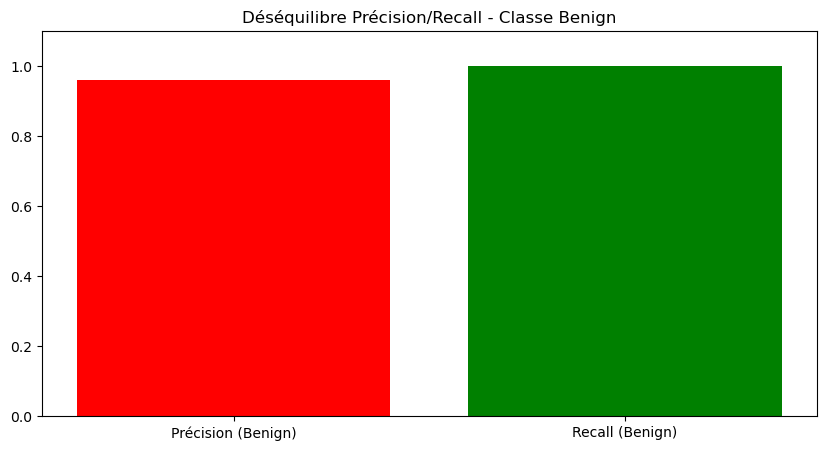

In [ ]:
# Récupération automatique des valeurs depuis le dictionnaire `metrics`
precision_benign = metrics['Précision']['Benign']
recall_benign = metrics['Recall']['Benign']

# Création du graphique
plt.figure(figsize=(10, 5))
plt.bar(['Précision (Benign)', 'Recall (Benign)'],
        [precision_benign, recall_benign],
        color=['red', 'green'])

plt.ylim(0, 1.1)
plt.title('Déséquilibre Précision/Recall - Classe Benign')

# Sauvegarde et affichage
plt.savefig("Desequilibre-Precision-Recall-Benign.png")
plt.show()

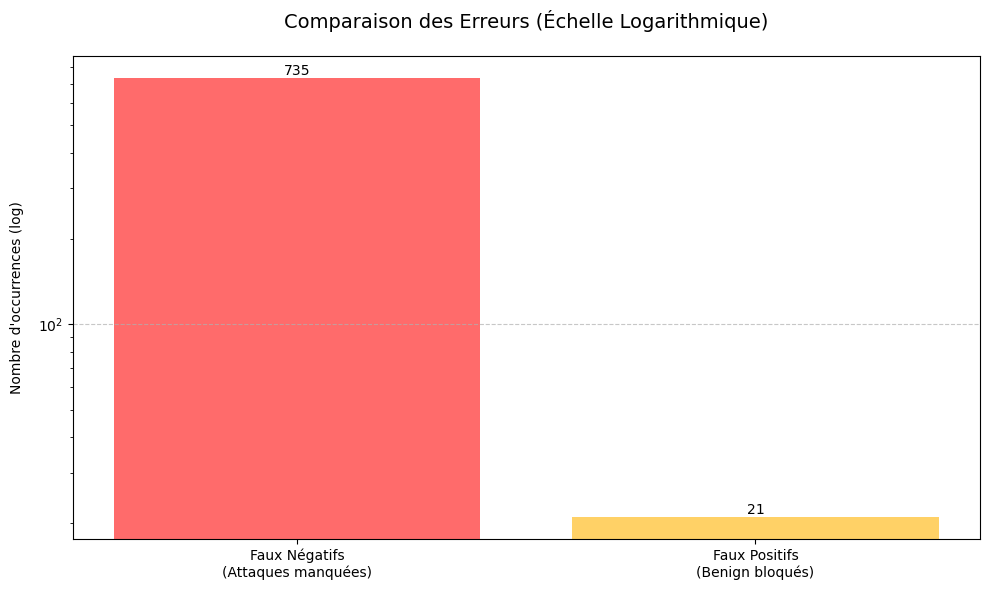

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extraction automatique depuis la matrice de confusion
TN, FP, FN, TP = cm.ravel()
values = [FN, FP]  # Faux Négatifs, Faux Positifs

# Données du graphique
labels = ['Faux Négatifs\n(Attaques manquées)', 'Faux Positifs\n(Benign bloqués)']
colors = ['#ff6b6b', '#ffd166']

# Création du graphique
fig, ax = plt.subplots(figsize=(10, 6))

# Barres avec échelle log pour voir les FP
bars = ax.bar(labels, values, color=colors, log=True)

# Ajout des valeurs exactes sur les barres
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom')

# Mise en forme
ax.set_title('Comparaison des Erreurs (Échelle Logarithmique)', pad=20, fontsize=14)
ax.set_ylabel('Nombre d\'occurrences (log)', labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("FN-vs-FP.png")
plt.show()

# XGBoost

In [11]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.1/318.1 MB 2.2 MB/s eta 0:00:00


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score, roc_curve, roc_auc_score
import time
import joblib
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.utils import resample
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [ ]:
# 1. Initialisation du modèle XGBoost avec des paramètres optimisés
model = XGBClassifier(
    n_estimators=8,           # Nombre d'arbres (peut être réduit pour accélérer)
    max_depth=15,                # Profondeur maximale des arbres
    learning_rate=0.1,          # Taux d'apprentissage
    subsample=0.8,              #% Pourcentage d'Echantillons utilisés par arbre
    colsample_bytree=0.8,       #% Pourcentage de features utilisés par arbre
    objective='binary:logistic', # Pour classification binaire
    n_jobs=-1,                  # Utilise tous les cœurs CPU
    random_state=42,
    scale_pos_weight=len(y_train_adasyn[y_train_adasyn==0])/len(y_train_adasyn[y_train_adasyn==1]),  # Gestion du déséquilibre
    verbosity=1,
    gamma=0,
    eval_metric='logloss'       # Métrique d'évaluation
)

In [ ]:
# Mesure du temps d'entraînement
start_train = time.time()
model.fit(X_train_adasyn, y_train_adasyn,
          eval_set=[(X_test_normalized, y_test)],  # Validation sur le test set
          verbose=True)
end_train = time.time()


[0]	validation_0-logloss:0.59892
[1]	validation_0-logloss:0.52103
[2]	validation_0-logloss:0.45606
[3]	validation_0-logloss:0.40117
[4]	validation_0-logloss:0.35426
[5]	validation_0-logloss:0.31389
[6]	validation_0-logloss:0.27887
[7]	validation_0-logloss:0.24832


In [ ]:
# Sauvegarde du modèle
joblib.dump(model, 'modelv3_xgboost_new.pkl')

# Compression du modèle
zip_filename = 'v3_XGB_model_new.zip'
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write('modelv3_xgboost_new.pkl')
print(f"Modèle XGBoost sauvegardé et compressé avec succès dans : {zip_filename}")


Modèle XGBoost sauvegardé et compressé avec succès dans : v3_XGB_model_new.zip


In [ ]:
# Prédiction avec mesure du temps
start_pred = time.time()
y_pred = model.predict(X_test_normalized)
y_pred_prob = model.predict_proba(X_test_normalized)[:, 1]
end_pred = time.time()

In [ ]:
# Création du fichier de résultats
with open("resultats_analyse_xgboost.txt", "w", encoding="utf-8") as f:
    f.write("═"*60 + "\n")
    f.write("           RAPPORT D'ÉVALUATION DU MODÈLE XGBOOST           \n")
    f.write("═"*60 + "\n\n")

In [ ]:
# Évaluation
report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)

# Affichage console
print("Classification Report :\n", report)
print("Confusion Matrix :\n", matrix)

# Sauvegarde dans le fichier texte
with open("resultats_analyse_xgboost.txt", "a", encoding="utf-8") as f:
    f.write("=== RAPPORT DE CLASSIFICATION ===\n")
    f.write(report + "\n")
    f.write("=== MATRICE DE CONFUSION ===\n")
    f.write(np.array2string(matrix, separator=' ') + "\n\n")


Classification Report :
               precision    recall  f1-score   support

           0       0.88      1.00      0.94     17059
           1       1.00      1.00      1.00  14593036

    accuracy                           1.00  14610095
   macro avg       0.94      1.00      0.97  14610095
weighted avg       1.00      1.00      1.00  14610095

Confusion Matrix :
 [[   17044       15]
 [    2318 14590718]]


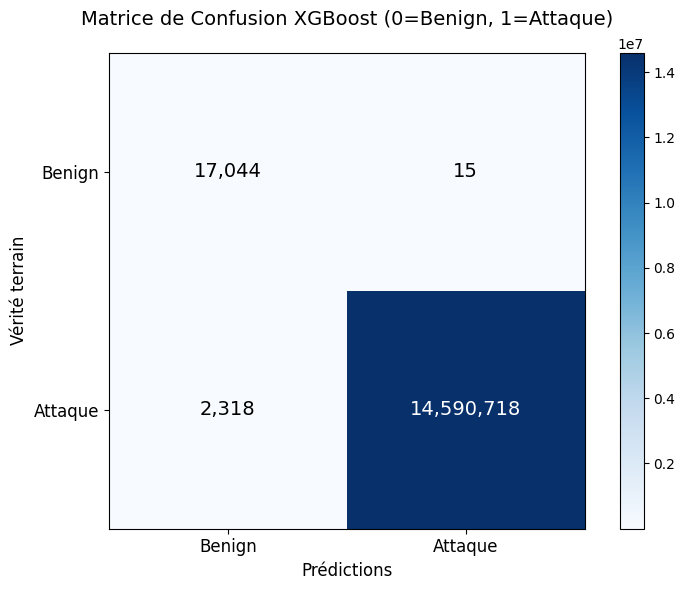

In [ ]:
# Visualisation matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matrice de Confusion XGBoost (0=Benign, 1=Attaque)', fontsize=14, pad=20)
plt.colorbar()
plt.xticks([0, 1], ['Benign', 'Attaque'], fontsize=12)
plt.yticks([0, 1], ['Benign', 'Attaque'], fontsize=12)
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Vérité terrain', fontsize=12)

thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i, j]:,}",
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=14)

plt.tight_layout()
plt.savefig('matrice_confusion_XGB.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Calcul des métriques supplémentaires
TN, FP, FN, TP = cm.ravel()
FPR = FP / (FP + TN)
FNR = FN / (FN + TP)

print(f""" - Taux de Faux Positifs (FPR) : {FPR:.4f}""")
print(f""" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}""")

with open("resultats_analyse_xgboost.txt", "a", encoding="utf-8") as f:
    f.write(f" - Taux de Faux Positifs (FPR) : {FPR:.4f}\n")
    f.write(f" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}\n\n")

 - Taux de Faux Positifs (FPR) : 0.0009
 - Taux de Faux Négatifs (Attaques manquées) FNR: 0.0002


In [ ]:
# Temps d'exécution
print(f"Temps de prédiction : {end_pred - start_pred:.2f} secondes")
print(f"Temps d'entrainement : {end_train - start_train:.2f} secondes")

with open("resultats_analyse_xgboost.txt", "a", encoding="utf-8") as f:
    f.write(f"Temps de prédiction : {end_pred - start_pred:.2f} secondes\n\n")
    f.write(f"Temps d'entrainement  : {end_train - start_train:.2f} secondes\n\n")

Temps de prédiction : 3.21 secondes
Temps d'entrainement : 64.30 secondes


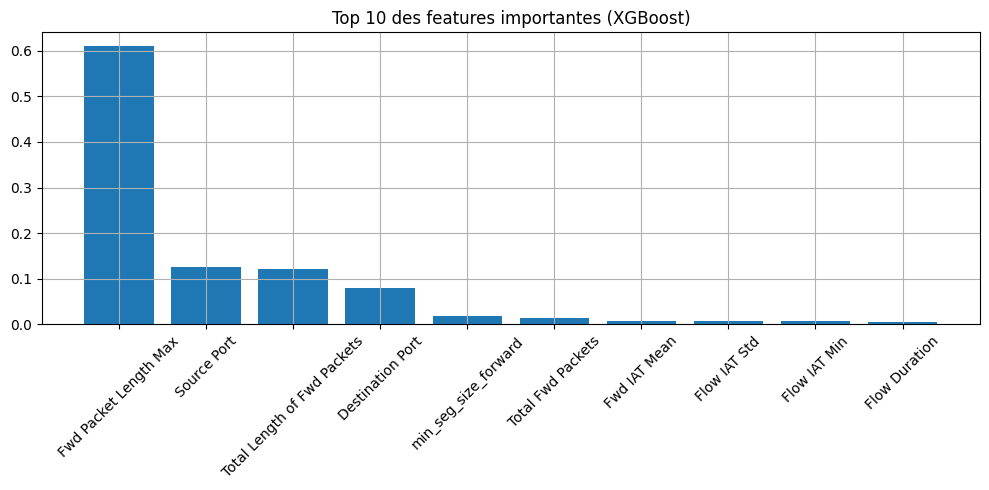

In [ ]:
# Feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[-10:][::-1]  # top 10
features = X_test.columns[indices]

plt.figure(figsize=(10, 5))
plt.title("Top 10 des features importantes (XGBoost)")
plt.bar(range(len(indices)), importances[indices], align="center")
plt.xticks(range(len(indices)), features, rotation=45)
plt.tight_layout()
plt.grid(True)
plt.savefig("feature_importance_XGB.png")
plt.show()

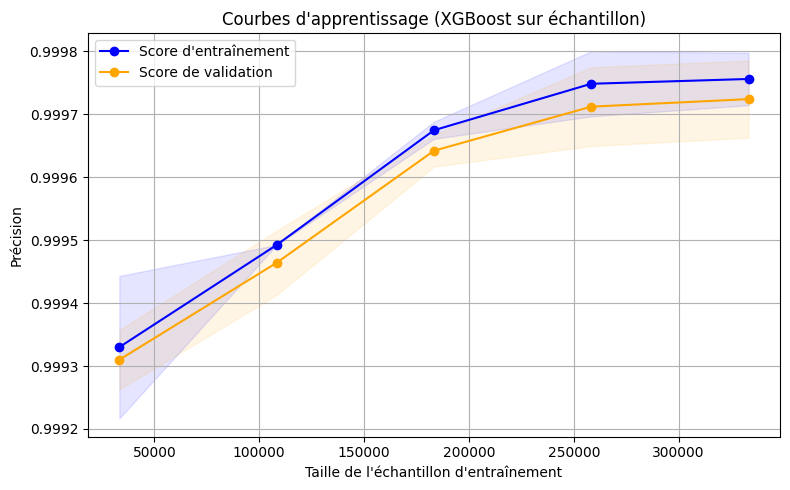

In [ ]:
# Courbes d'apprentissage (sur échantillon réduit)
X_sample, y_sample = resample(X_test, y_test, n_samples=500000, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    model, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d'apprentissage (XGBoost sur échantillon)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_XGB.png")
plt.show()

In [12]:
import joblib
modelxg = joblib.load('modelv3_xgboost_new.pkl')
print(type(modelxg))


<class 'xgboost.sklearn.XGBClassifier'>


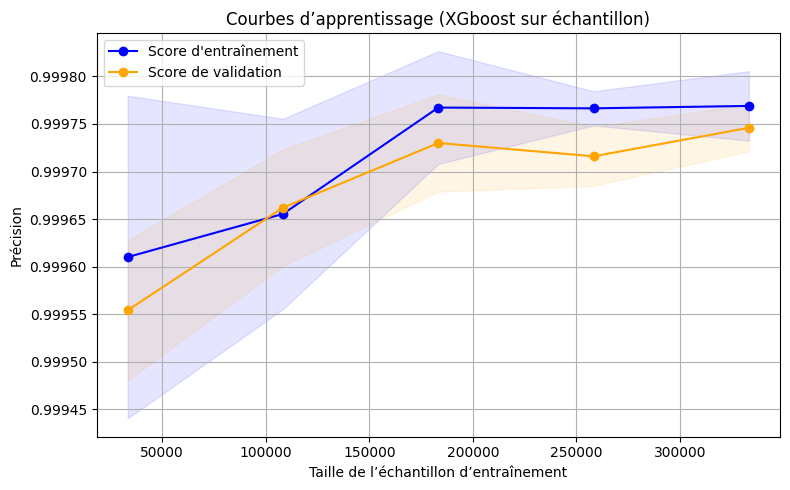

In [13]:

from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_train_adasyn, y_train_adasyn, n_samples=500000, random_state=42)

# Génération des courbes d’apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    modelxg, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d’apprentissage (XGboost sur échantillon)")
plt.xlabel("Taille de l’échantillon d’entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_train_xg_v3.png")
plt.show()


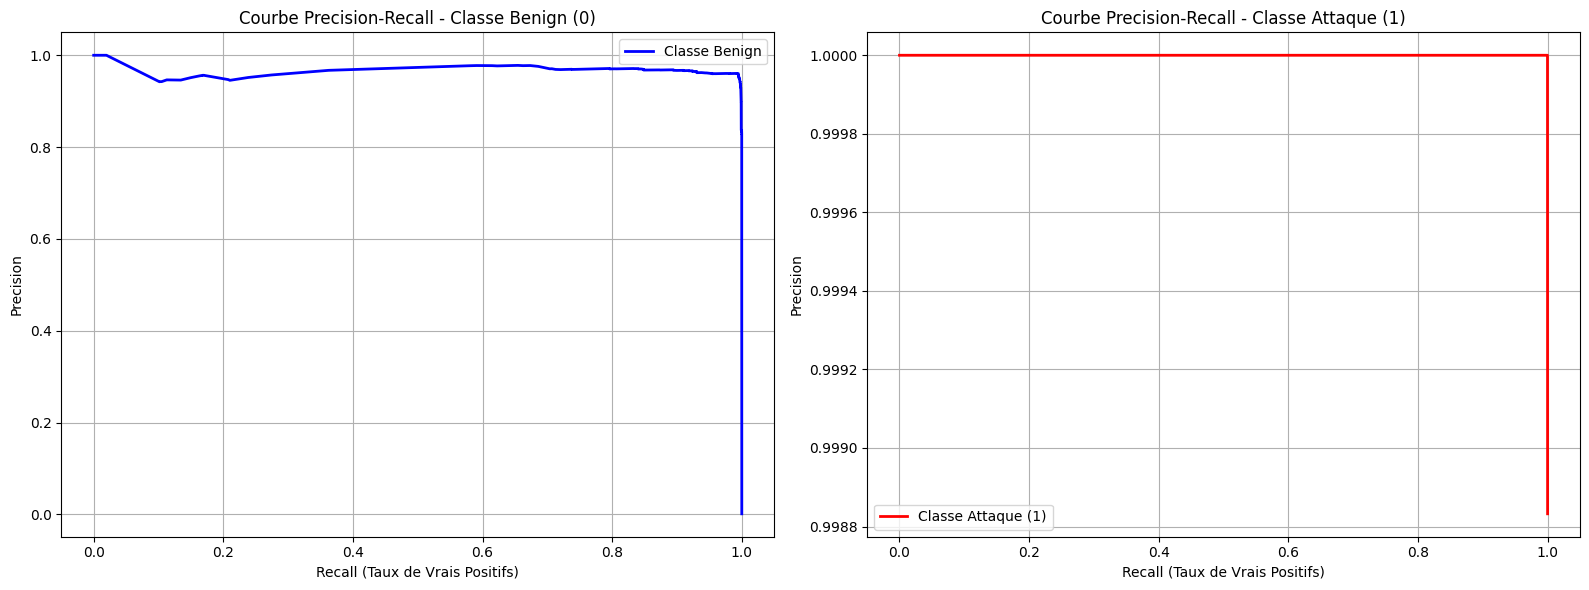

In [ ]:
# Courbes Precision-Recall par classe
plt.figure(figsize=(16, 6))

# Classe Benign
plt.subplot(1, 2, 1)
precision_benign, recall_benign, _ = precision_recall_curve(y_test, 1 - y_pred_prob, pos_label=0)
plt.plot(recall_benign, precision_benign, color='blue', lw=2, label='Classe Benign')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - Classe Benign (0)')
plt.legend()
plt.grid()
plt.autoscale(enable=True, axis='both', tight=False)

# Classe Attaque
plt.subplot(1, 2, 2)
precision_attack, recall_attack, _ = precision_recall_curve(y_test, y_pred_prob, pos_label=1)
plt.plot(recall_attack, precision_attack, color='red', lw=2, label='Classe Attaque (1)')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - Classe Attaque (1)')
plt.legend()
plt.grid()
plt.autoscale(enable=True, axis='both', tight=False)

plt.tight_layout()
plt.savefig("courbes-precision-recall-0-1_XGB.png")
plt.show()

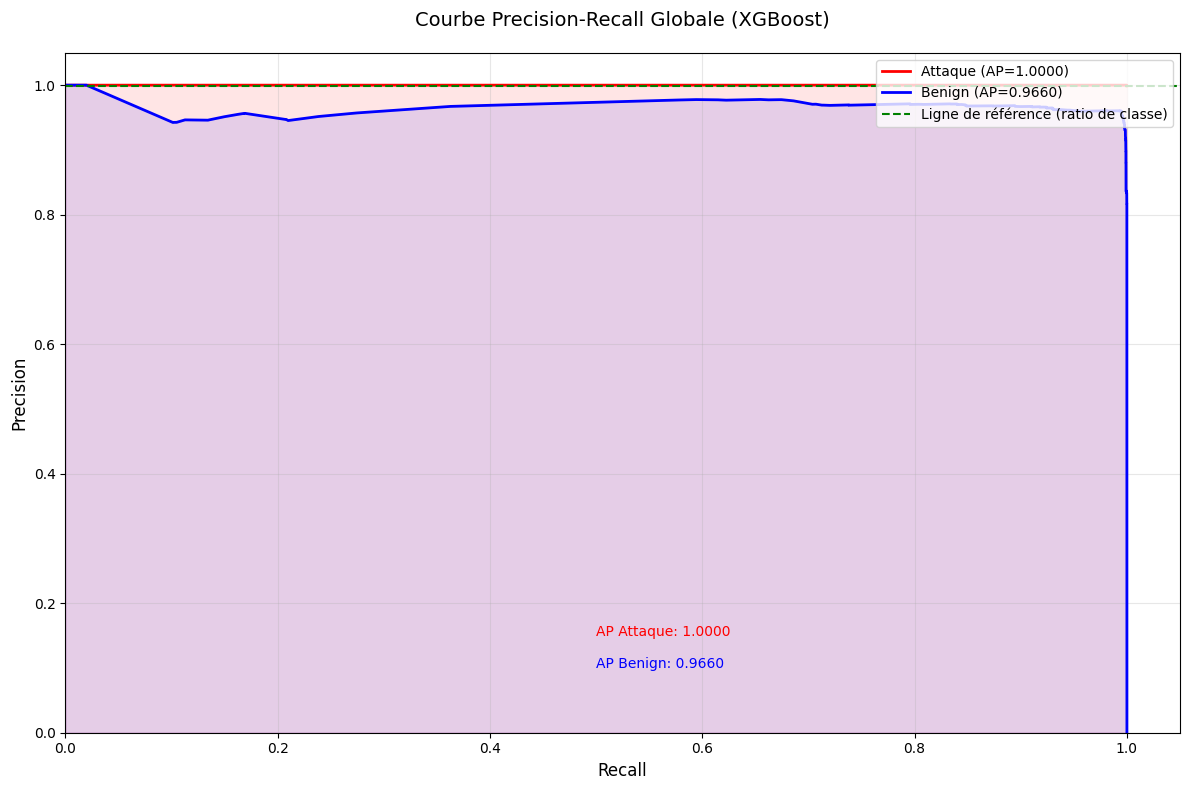

In [ ]:
# Courbe Precision-Recall globale
ap_attack = average_precision_score(y_test, y_pred_prob, pos_label=1)
ap_benign = average_precision_score(y_test, 1 - y_pred_prob, pos_label=0)

plt.figure(figsize=(12, 8))
plt.plot(recall_attack, precision_attack, color='red', lw=2,
         label=f'Attaque (AP={ap_attack:.4f})', linestyle='-')
plt.plot(recall_benign, precision_benign, color='blue', lw=2,
         label=f'Benign (AP={ap_benign:.4f})', linestyle='-')
plt.axhline(y=len(y_test[y_test==1])/len(y_test), color='green', linestyle='--',
            label='Ligne de référence (ratio de classe)')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Courbe Precision-Recall Globale (XGBoost)', fontsize=14, pad=20)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])

plt.text(0.5, 0.15, f"AP Attaque: {ap_attack:.4f}", color='red', fontsize=10)
plt.text(0.5, 0.10, f"AP Benign: {ap_benign:.4f}", color='blue', fontsize=10)

plt.fill_between(recall_attack, precision_attack, color='red', alpha=0.1)
plt.fill_between(recall_benign, precision_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-precision-recall-global_XGB.png")
plt.show()

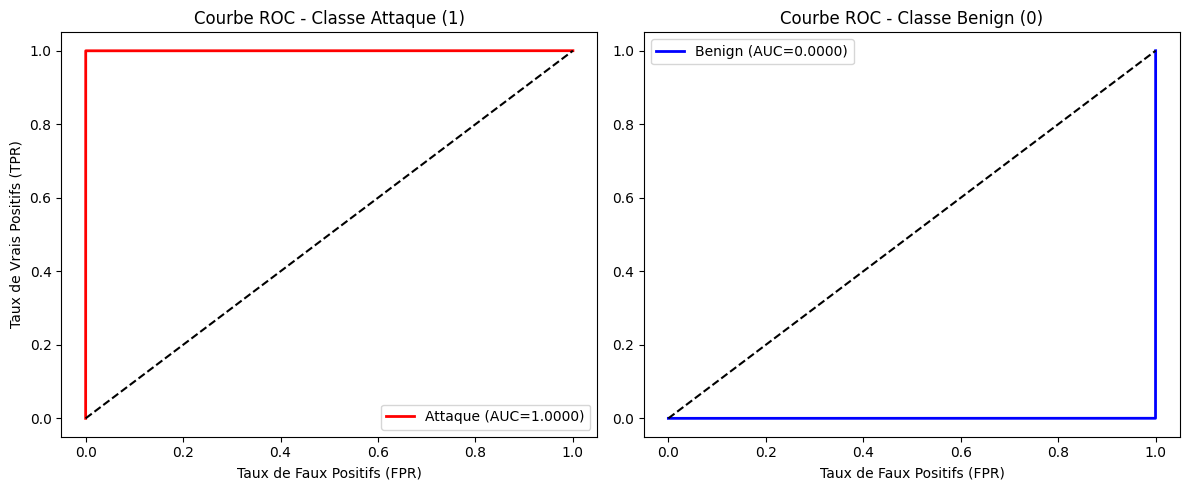

In [ ]:
# Courbes ROC
fpr_attack, tpr_attack, _ = roc_curve(y_test, y_pred_prob, pos_label=1)
auc_attack = roc_auc_score(y_test, y_pred_prob)

fpr_benign, tpr_benign, _ = roc_curve(y_test, y_pred_prob, pos_label=0)
auc_benign = roc_auc_score(y_test, 1 - y_pred_prob)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_attack, tpr_attack, color='red', lw=2, label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC - Classe Attaque (1)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2, label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.title('Courbe ROC - Classe Benign (0)')
plt.legend()

plt.tight_layout()
plt.savefig("courbes-ROC-0-1_XGB.png")
plt.show()

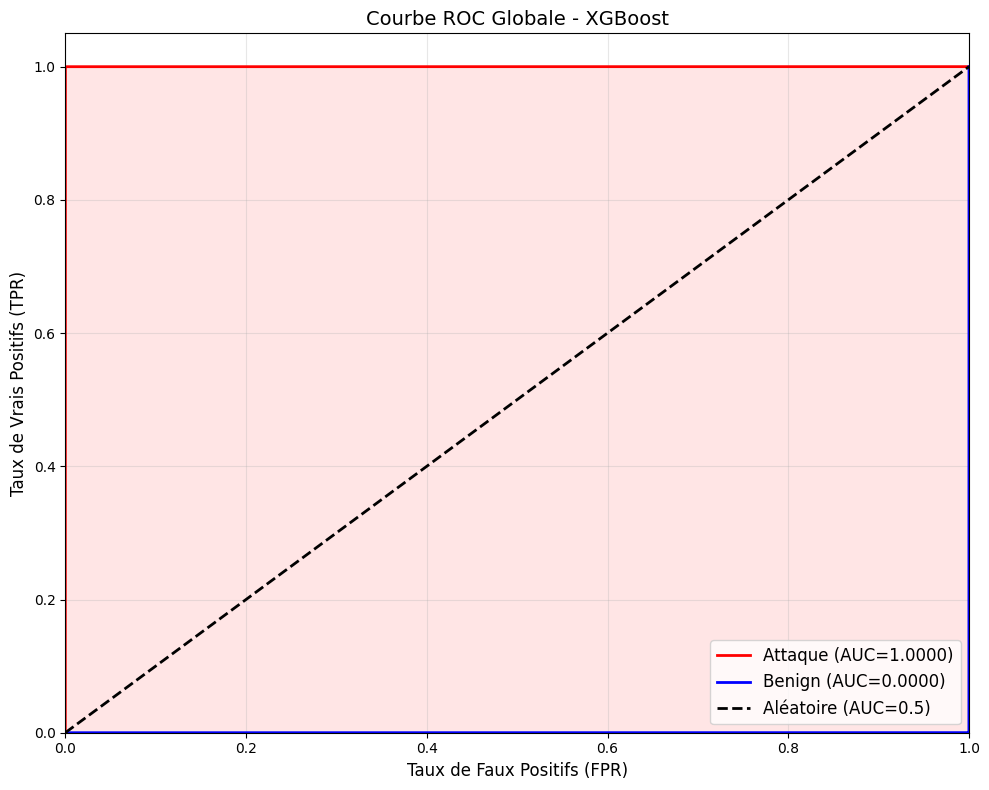

In [ ]:
# Courbe ROC globale
auc_global = (auc_attack + auc_benign) / 2

plt.figure(figsize=(10, 8))
plt.plot(fpr_attack, tpr_attack, color='red', lw=2,
         label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2,
         label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Aléatoire (AUC=0.5)')

plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC Globale - XGBoost', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.fill_between(fpr_attack, tpr_attack, color='red', alpha=0.1)
plt.fill_between(fpr_benign, tpr_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-ROC-globale_XGB.png")
plt.show()

In [ ]:
# Affichage des performances AUC-ROC
print("\n" + "═"*50)
print(" PERFORMANCE DU MODÈLE XGBOOST ".center(50, "~"))
print("═"*50)
print(f"\n\033[1m• AUC-ROC Classe Attaque (1)\033[0m : {auc_attack:.6f}")
print(f"\033[1m• AUC-ROC Classe Benign (0)\033[0m  : {auc_benign:.6f}")
print(f"\n\033[1m• AUC-ROC Global (macro)\033[0m     : {auc_global:.6f}")
print("\n" + "═"*50)

with open("resultats_analyse_xgboost.txt", "a", encoding="utf-8") as f:
    f.write("\n" + "═"*50 + "\n")
    f.write(" PERFORMANCE DU MODÈLE XGBOOST ".center(50, "~") + "\n")
    f.write("═"*50 + "\n")
    f.write(f"\n• AUC-ROC Classe Attaque (1) : {auc_attack:.6f}\n")
    f.write(f"• AUC-ROC Classe Benign (0)  : {auc_benign:.6f}\n")
    f.write(f"\n• AUC-ROC Global (macro)     : {auc_global:.6f}\n")
    f.write("═"*50 + "\n\n")


══════════════════════════════════════════════════
~~~~~~~~~ PERFORMANCE DU MODÈLE XGBOOST ~~~~~~~~~~
══════════════════════════════════════════════════

• AUC-ROC Classe Attaque (1) : 0.999981
• AUC-ROC Classe Benign (0)  : 0.000019

• AUC-ROC Global (macro)     : 0.500000

══════════════════════════════════════════════════


In [ ]:
# Tableau récapitulatif des métriques
metrics = {
    'Précision': {
        'Benign': precision_score(y_test, y_pred, pos_label=0),
        'Attaque': precision_score(y_test, y_pred, pos_label=1),
        'Global': precision_score(y_test, y_pred, average='macro')
    },
    'Recall': {
        'Benign': recall_score(y_test, y_pred, pos_label=0),
        'Attaque': recall_score(y_test, y_pred, pos_label=1),
        'Global': recall_score(y_test, y_pred, average='macro')
    },
    'F1-Score': {
        'Benign': f1_score(y_test, y_pred, pos_label=0),
        'Attaque': f1_score(y_test, y_pred, pos_label=1),
        'Global': f1_score(y_test, y_pred, average='macro')
    },
    'Accuracy': {
        'Global': accuracy_score(y_test, y_pred)
    }
}

print("╔═════════════════════════════════════════════╗")
print("║          PERFORMANCE DU MODÈLE XGBOOST      ║")
print("╠══════════════╦══════════╦══════════╦════════╣")
print("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║")
print("╠══════════════╬══════════╬══════════╬════════╣")

for metric_name, values in metrics.items():
    if metric_name == 'Accuracy':
        print(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║")
    else:
        print(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║")

print("╚══════════════╩══════════╩══════════╩════════╝")

with open("resultats_analyse_xgboost.txt", "a", encoding="utf-8") as f:
    f.write("╔═════════════════════════════════════════════╗\n")
    f.write("║          PERFORMANCE DU MODÈLE XGBOOST      ║\n")
    f.write("╠══════════════╦══════════╦══════════╦════════╣\n")
    f.write("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║\n")
    f.write("╠══════════════╬══════════╬══════════╬════════╣\n")

    for metric_name, values in metrics.items():
        if metric_name == 'Accuracy':
            f.write(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║\n")
        else:
            f.write(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║\n")

    f.write("╚══════════════╩══════════╩══════════╩════════╝\n\n")

╔═════════════════════════════════════════════╗
║          PERFORMANCE DU MODÈLE XGBOOST      ║
╠══════════════╦══════════╦══════════╦════════╣
║   Métrique   ║  Benign  ║ Attaque  ║ Global ║
╠══════════════╬══════════╬══════════╬════════╣
║ Précision    ║ 0.8803   ║ 1.0000   ║ 0.9401 ║
║ Recall       ║ 0.9991   ║ 0.9998   ║ 0.9995 ║
║ F1-Score     ║ 0.9359   ║ 0.9999   ║ 0.9679 ║
║ Accuracy     ║          ║          ║ 0.9998 ║
╚══════════════╩══════════╩══════════╩════════╝


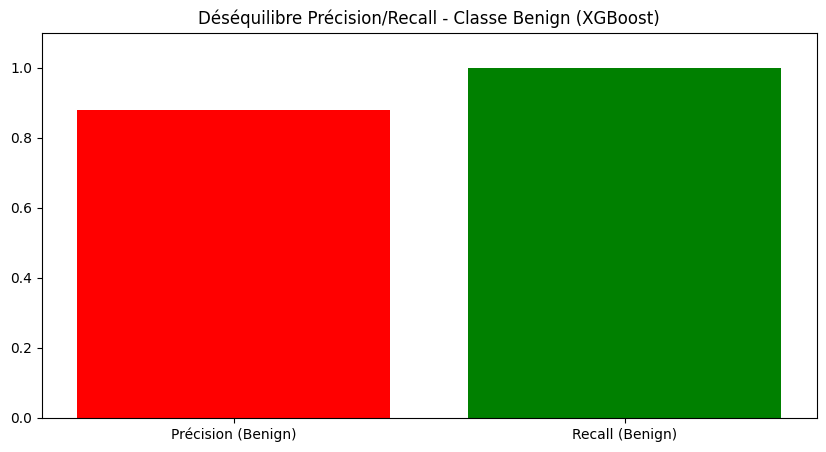

In [ ]:
# Déséquilibre Précision/Recall
precision_benign = metrics['Précision']['Benign']
recall_benign = metrics['Recall']['Benign']

plt.figure(figsize=(10, 5))
plt.bar(['Précision (Benign)', 'Recall (Benign)'],
        [precision_benign, recall_benign],
        color=['red', 'green'])
plt.ylim(0, 1.1)
plt.title('Déséquilibre Précision/Recall - Classe Benign (XGBoost)')
plt.savefig("Desequilibre-Precision-Recall-Benign_XGB.png")
plt.show()

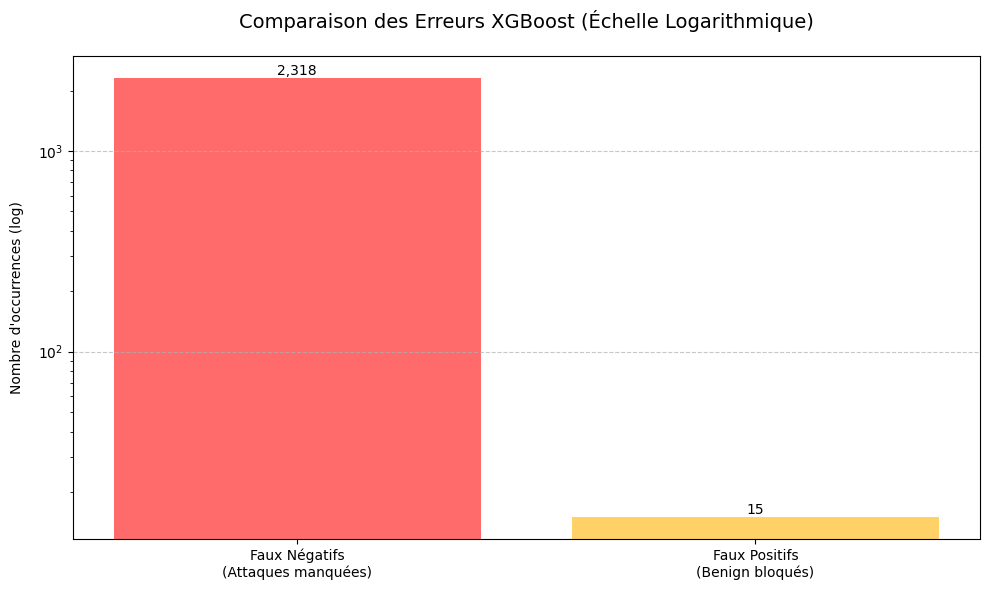

In [ ]:
# Comparaison des erreurs
values = [FN, FP]
labels = ['Faux Négatifs\n(Attaques manquées)', 'Faux Positifs\n(Benign bloqués)']
colors = ['#ff6b6b', '#ffd166']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, color=colors, log=True)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom')

ax.set_title('Comparaison des Erreurs XGBoost (Échelle Logarithmique)', pad=20, fontsize=14)
ax.set_ylabel("Nombre d'occurrences (log)", labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("FN-vs-FP_XGB.png")
plt.show()

# Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score, roc_curve, roc_auc_score
import time
import joblib
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.utils import resample
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [ ]:
# 1. Initialisation du modèle Naive Bayes
model = GaussianNB(
    priors=None,  # Les probabilités a priori des classes. Si None, seront calculées à partir des données
    var_smoothing=1e-9  # Partie de la plus grande variance qui est ajoutée aux variances pour la stabilité
)

In [ ]:
# Mesure du temps d'entraînement
start_train = time.time()
model.fit(X_train_adasyn, y_train_adasyn)
end_train = time.time()


In [ ]:
# Sauvegarde du modèle
joblib.dump(model, 'modelv3_naive_bayes_new.pkl')

# Compression du modèle
zip_filename = 'v3_NB_model_new.zip'
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write('modelv3_naive_bayes_new.pkl')
print(f"Modèle Naive Bayes sauvegardé et compressé avec succès dans : {zip_filename}")


Modèle Naive Bayes sauvegardé et compressé avec succès dans : v3_NB_model_new.zip


In [ ]:
# Prédiction avec mesure du temps
start_pred = time.time()
y_pred = model.predict(X_test_normalized)
y_pred_prob = model.predict_proba(X_test_normalized)[:, 1]
end_pred = time.time()

In [ ]:
# Création du fichier de résultats
with open("resultats_analyse_naive_bayes.txt", "w", encoding="utf-8") as f:
    f.write("═"*60 + "\n")
    f.write("           RAPPORT D'ÉVALUATION DU MODÈLE NAIVE BAYES           \n")
    f.write("═"*60 + "\n\n")


In [ ]:
# Évaluation
report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)

# Affichage console
print("Classification Report :\n", report)
print("Confusion Matrix :\n", matrix)

# Sauvegarde dans le fichier texte
with open("resultats_analyse_naive_bayes.txt", "a", encoding="utf-8") as f:
    f.write("=== RAPPORT DE CLASSIFICATION ===\n")
    f.write(report + "\n")
    f.write("=== MATRICE DE CONFUSION ===\n")
    f.write(np.array2string(matrix, separator=' ') + "\n\n")


Classification Report :
               precision    recall  f1-score   support

           0       0.02      0.13      0.04     17059
           1       1.00      0.99      1.00  14593036

    accuracy                           0.99  14610095
   macro avg       0.51      0.56      0.52  14610095
weighted avg       1.00      0.99      1.00  14610095

Confusion Matrix :
 [[    2200    14859]
 [   94461 14498575]]


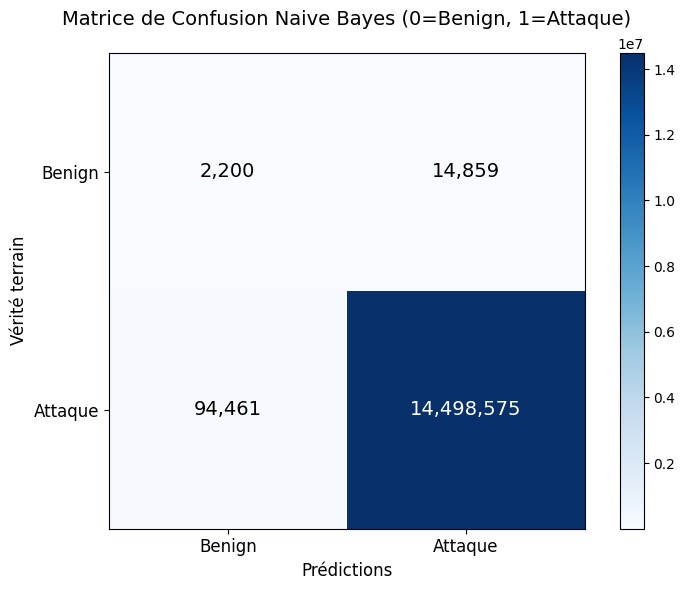

In [ ]:
# Visualisation matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matrice de Confusion Naive Bayes (0=Benign, 1=Attaque)', fontsize=14, pad=20)
plt.colorbar()
plt.xticks([0, 1], ['Benign', 'Attaque'], fontsize=12)
plt.yticks([0, 1], ['Benign', 'Attaque'], fontsize=12)
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Vérité terrain', fontsize=12)

thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i, j]:,}",
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=14)

plt.tight_layout()
plt.savefig('matrice_confusion_NB.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Calcul des métriques supplémentaires
TN, FP, FN, TP = cm.ravel()
FPR = FP / (FP + TN)
FNR = FN / (FN + TP)

print(f""" - Taux de Faux Positifs (FPR) : {FPR:.4f}""")
print(f""" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}""")

with open("resultats_analyse_naive_bayes.txt", "a", encoding="utf-8") as f:
    f.write(f" - Taux de Faux Positifs (FPR) : {FPR:.4f}\n")
    f.write(f" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}\n\n")


 - Taux de Faux Positifs (FPR) : 0.8710
 - Taux de Faux Négatifs (Attaques manquées) FNR: 0.0065


In [ ]:
# Temps d'exécution
print(f"Temps de prédiction : {end_pred - start_pred:.2f} secondes")
print(f"Temps d'entrainement : {end_train - start_train:.2f} secondes")

with open("resultats_analyse_naive_bayes.txt", "a", encoding="utf-8") as f:
    f.write(f"Temps de prédiction : {end_pred - start_pred:.2f} secondes\n\n")
    f.write(f"Temps d'entrainement  : {end_train - start_train:.2f} secondes\n\n")


Temps de prédiction : 10.21 secondes
Temps d'entrainement : 24.04 secondes


In [ ]:
# Note: Naive Bayes n'a pas de feature importance comme les arbres de décision
# Nous allons donc sauter cette partie ou utiliser une alternative

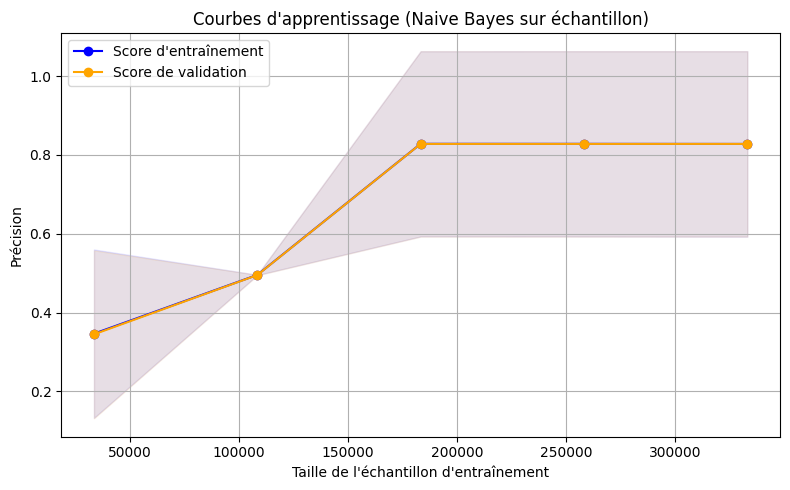

In [ ]:
# Courbes d'apprentissage (sur échantillon réduit)
X_sample, y_sample = resample(X_test, y_test, n_samples=500000, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    model, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d'apprentissage (Naive Bayes sur échantillon)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_NB.png")
plt.show()

In [14]:
import joblib
modelnb = joblib.load('modelv3_naive_bayes_new.pkl')
print(type(modelnb))


<class 'sklearn.naive_bayes.GaussianNB'>


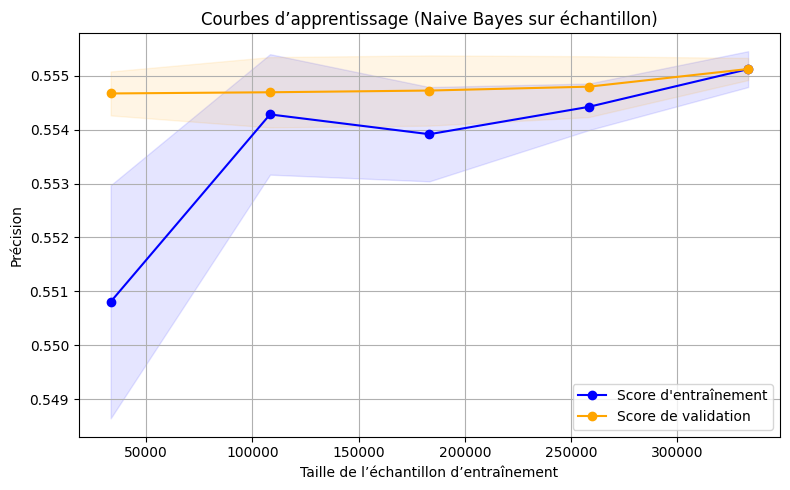

In [15]:

from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_train_adasyn, y_train_adasyn, n_samples=500000, random_state=42)

# Génération des courbes d’apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    modelnb, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d’apprentissage (Naive Bayes sur échantillon)")
plt.xlabel("Taille de l’échantillon d’entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_train_nb_v3.png")
plt.show()


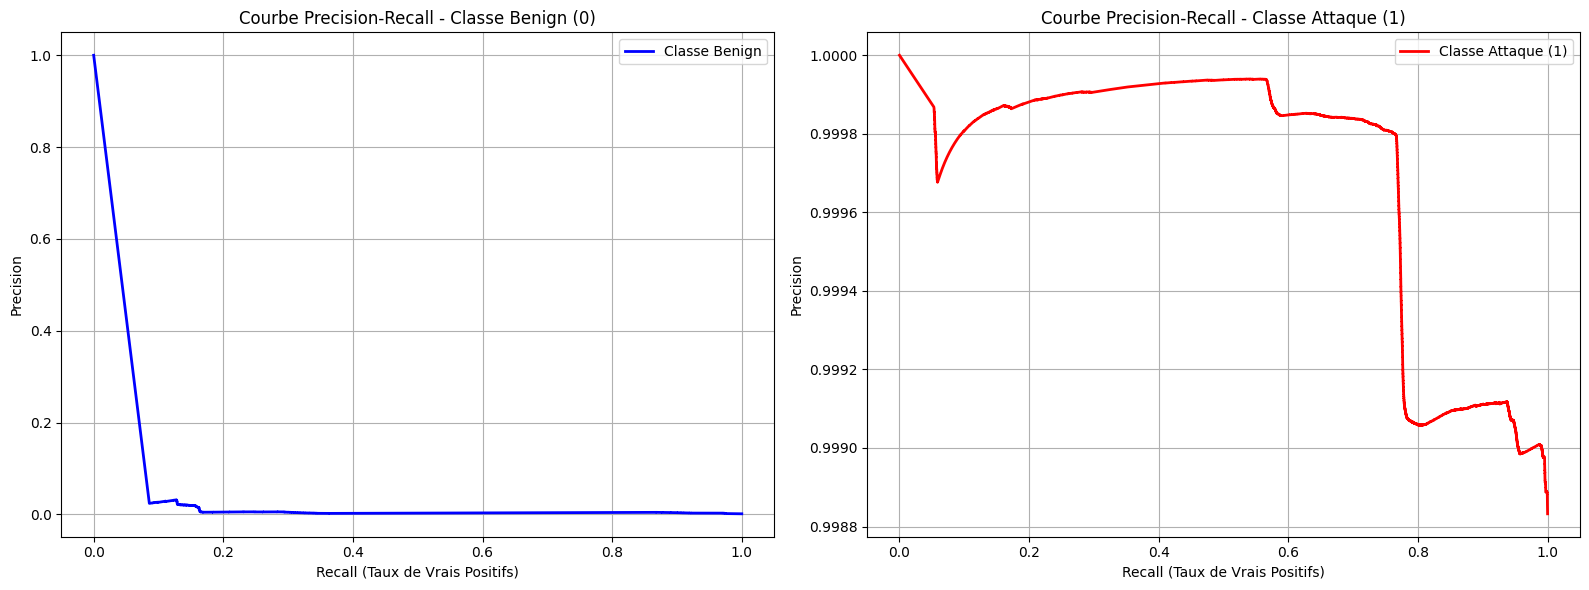

In [ ]:
# Courbes Precision-Recall par classe
plt.figure(figsize=(16, 6))

# Classe Benign
plt.subplot(1, 2, 1)
precision_benign, recall_benign, _ = precision_recall_curve(y_test, 1 - y_pred_prob, pos_label=0)
plt.plot(recall_benign, precision_benign, color='blue', lw=2, label='Classe Benign')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - Classe Benign (0)')
plt.legend()
plt.grid()
plt.autoscale(enable=True, axis='both', tight=False)

# Classe Attaque
plt.subplot(1, 2, 2)
precision_attack, recall_attack, _ = precision_recall_curve(y_test, y_pred_prob, pos_label=1)
plt.plot(recall_attack, precision_attack, color='red', lw=2, label='Classe Attaque (1)')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - Classe Attaque (1)')
plt.legend()
plt.grid()
plt.autoscale(enable=True, axis='both', tight=False)

plt.tight_layout()
plt.savefig("courbes-precision-recall-0-1_NB.png")
plt.show()

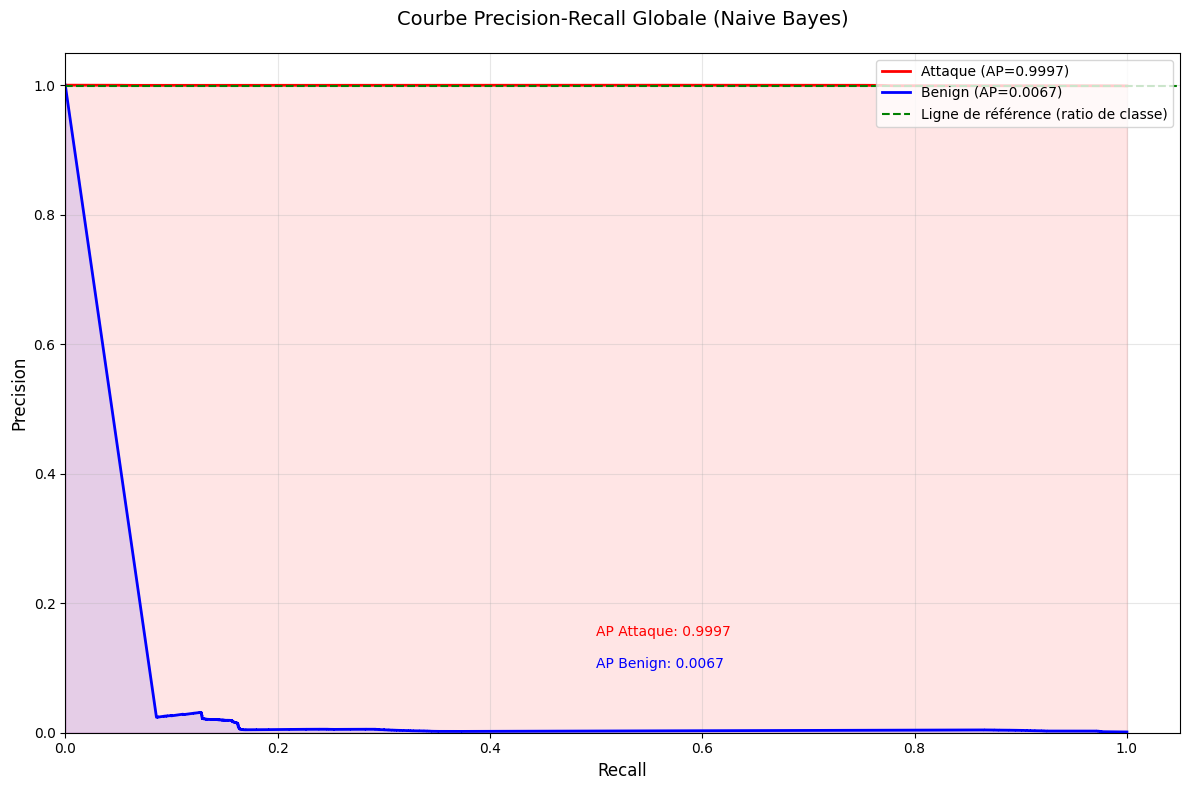

In [ ]:
# Courbe Precision-Recall globale
ap_attack = average_precision_score(y_test, y_pred_prob, pos_label=1)
ap_benign = average_precision_score(y_test, 1 - y_pred_prob, pos_label=0)

plt.figure(figsize=(12, 8))
plt.plot(recall_attack, precision_attack, color='red', lw=2,
         label=f'Attaque (AP={ap_attack:.4f})', linestyle='-')
plt.plot(recall_benign, precision_benign, color='blue', lw=2,
         label=f'Benign (AP={ap_benign:.4f})', linestyle='-')
plt.axhline(y=len(y_test[y_test==1])/len(y_test), color='green', linestyle='--',
            label='Ligne de référence (ratio de classe)')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Courbe Precision-Recall Globale (Naive Bayes)', fontsize=14, pad=20)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])

plt.text(0.5, 0.15, f"AP Attaque: {ap_attack:.4f}", color='red', fontsize=10)
plt.text(0.5, 0.10, f"AP Benign: {ap_benign:.4f}", color='blue', fontsize=10)

plt.fill_between(recall_attack, precision_attack, color='red', alpha=0.1)
plt.fill_between(recall_benign, precision_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-precision-recall-global_NB.png")
plt.show()

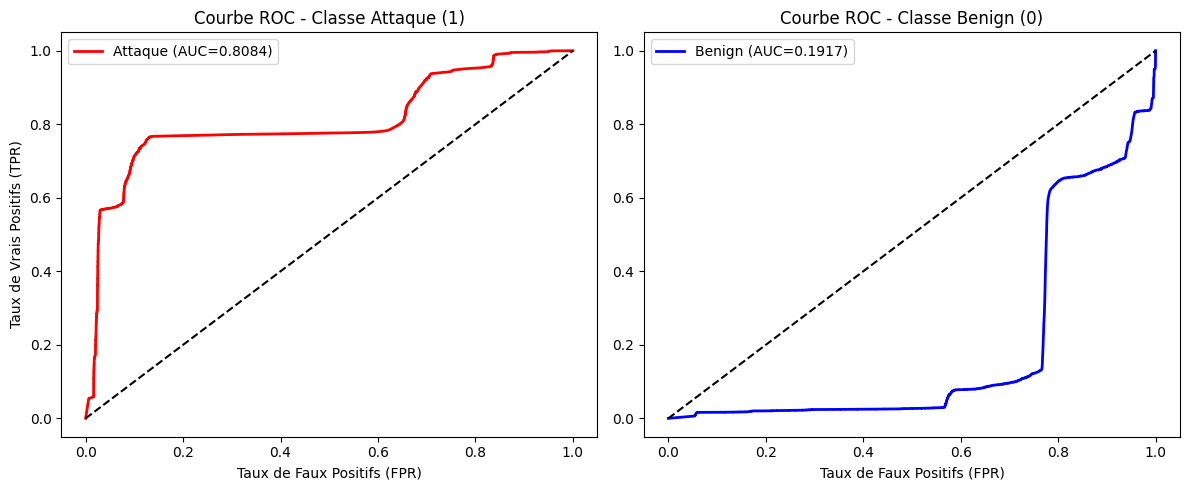

In [ ]:
# Courbes ROC
fpr_attack, tpr_attack, _ = roc_curve(y_test, y_pred_prob, pos_label=1)
auc_attack = roc_auc_score(y_test, y_pred_prob)

fpr_benign, tpr_benign, _ = roc_curve(y_test, y_pred_prob, pos_label=0)
auc_benign = roc_auc_score(y_test, 1 - y_pred_prob)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_attack, tpr_attack, color='red', lw=2, label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC - Classe Attaque (1)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2, label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.title('Courbe ROC - Classe Benign (0)')
plt.legend()

plt.tight_layout()
plt.savefig("courbes-ROC-0-1_NB.png")
plt.show()

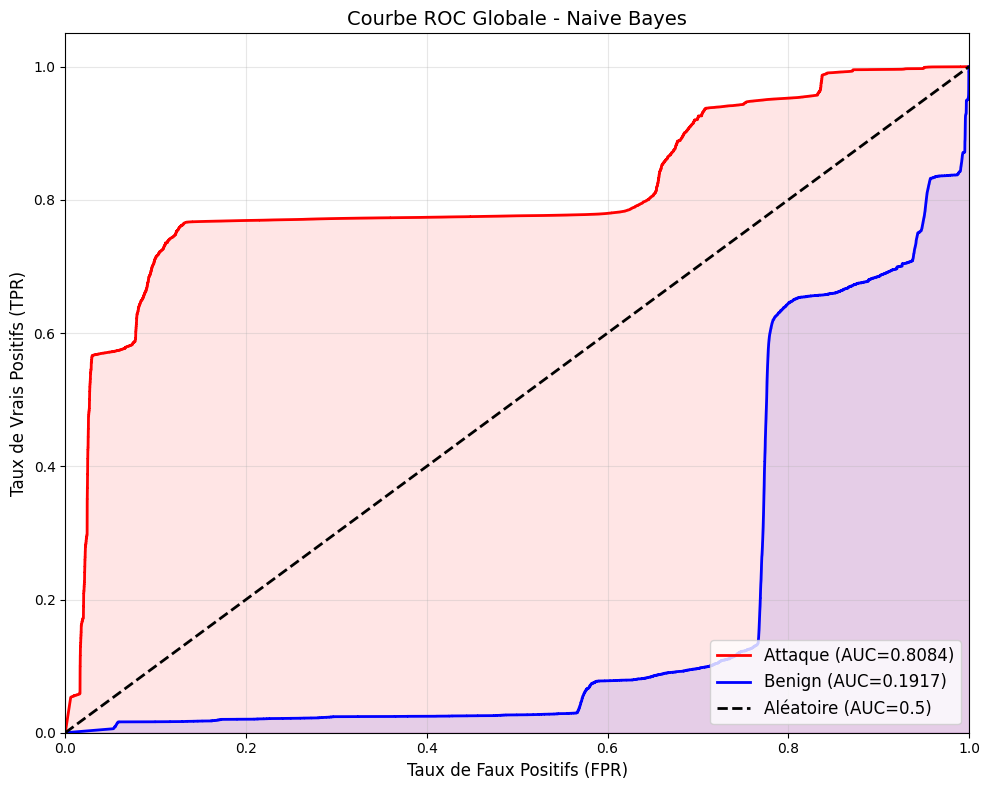

In [ ]:
# Courbe ROC globale
auc_global = (auc_attack + auc_benign) / 2

plt.figure(figsize=(10, 8))
plt.plot(fpr_attack, tpr_attack, color='red', lw=2,
         label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2,
         label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Aléatoire (AUC=0.5)')

plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC Globale - Naive Bayes', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.fill_between(fpr_attack, tpr_attack, color='red', alpha=0.1)
plt.fill_between(fpr_benign, tpr_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-ROC-globale_NB.png")
plt.show()

In [ ]:
# Affichage des performances AUC-ROC
print("\n" + "═"*50)
print(" PERFORMANCE DU MODÈLE NAIVE BAYES ".center(50, "~"))
print("═"*50)
print(f"\n\033[1m• AUC-ROC Classe Attaque (1)\033[0m : {auc_attack:.6f}")
print(f"\033[1m• AUC-ROC Classe Benign (0)\033[0m  : {auc_benign:.6f}")
print(f"\n\033[1m• AUC-ROC Global (macro)\033[0m     : {auc_global:.6f}")
print("\n" + "═"*50)

with open("resultats_analyse_naive_bayes.txt", "a", encoding="utf-8") as f:
    f.write("\n" + "═"*50 + "\n")
    f.write(" PERFORMANCE DU MODÈLE NAIVE BAYES ".center(50, "~") + "\n")
    f.write("═"*50 + "\n")
    f.write(f"\n• AUC-ROC Classe Attaque (1) : {auc_attack:.6f}\n")
    f.write(f"• AUC-ROC Classe Benign (0)  : {auc_benign:.6f}\n")
    f.write(f"\n• AUC-ROC Global (macro)     : {auc_global:.6f}\n")
    f.write("═"*50 + "\n\n")


══════════════════════════════════════════════════
~~~~~~~ PERFORMANCE DU MODÈLE NAIVE BAYES ~~~~~~~~
══════════════════════════════════════════════════

• AUC-ROC Classe Attaque (1) : 0.808354
• AUC-ROC Classe Benign (0)  : 0.191683

• AUC-ROC Global (macro)     : 0.500019

══════════════════════════════════════════════════


In [ ]:
# Tableau récapitulatif des métriques
metrics = {
    'Précision': {
        'Benign': precision_score(y_test, y_pred, pos_label=0),
        'Attaque': precision_score(y_test, y_pred, pos_label=1),
        'Global': precision_score(y_test, y_pred, average='macro')
    },
    'Recall': {
        'Benign': recall_score(y_test, y_pred, pos_label=0),
        'Attaque': recall_score(y_test, y_pred, pos_label=1),
        'Global': recall_score(y_test, y_pred, average='macro')
    },
    'F1-Score': {
        'Benign': f1_score(y_test, y_pred, pos_label=0),
        'Attaque': f1_score(y_test, y_pred, pos_label=1),
        'Global': f1_score(y_test, y_pred, average='macro')
    },
    'Accuracy': {
        'Global': accuracy_score(y_test, y_pred)
    }
}

print("╔═════════════════════════════════════════════╗")
print("║          PERFORMANCE DU MODÈLE NAIVE BAYES  ║")
print("╠══════════════╦══════════╦══════════╦════════╣")
print("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║")
print("╠══════════════╬══════════╬══════════╬════════╣")

for metric_name, values in metrics.items():
    if metric_name == 'Accuracy':
        print(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║")
    else:
        print(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║")

print("╚══════════════╩══════════╩══════════╩════════╝")

with open("resultats_analyse_naive_bayes.txt", "a", encoding="utf-8") as f:
    f.write("╔═════════════════════════════════════════════╗\n")
    f.write("║          PERFORMANCE DU MODÈLE NAIVE BAYES  ║\n")
    f.write("╠══════════════╦══════════╦══════════╦════════╣\n")
    f.write("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║\n")
    f.write("╠══════════════╬══════════╬══════════╬════════╣\n")

    for metric_name, values in metrics.items():
        if metric_name == 'Accuracy':
            f.write(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║\n")
        else:
            f.write(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║\n")

    f.write("╚══════════════╩══════════╩══════════╩════════╝\n\n")

╔═════════════════════════════════════════════╗
║          PERFORMANCE DU MODÈLE NAIVE BAYES  ║
╠══════════════╦══════════╦══════════╦════════╣
║   Métrique   ║  Benign  ║ Attaque  ║ Global ║
╠══════════════╬══════════╬══════════╬════════╣
║ Précision    ║ 0.0228   ║ 0.9990   ║ 0.5109 ║
║ Recall       ║ 0.1290   ║ 0.9935   ║ 0.5612 ║
║ F1-Score     ║ 0.0387   ║ 0.9962   ║ 0.5175 ║
║ Accuracy     ║          ║          ║ 0.9925 ║
╚══════════════╩══════════╩══════════╩════════╝


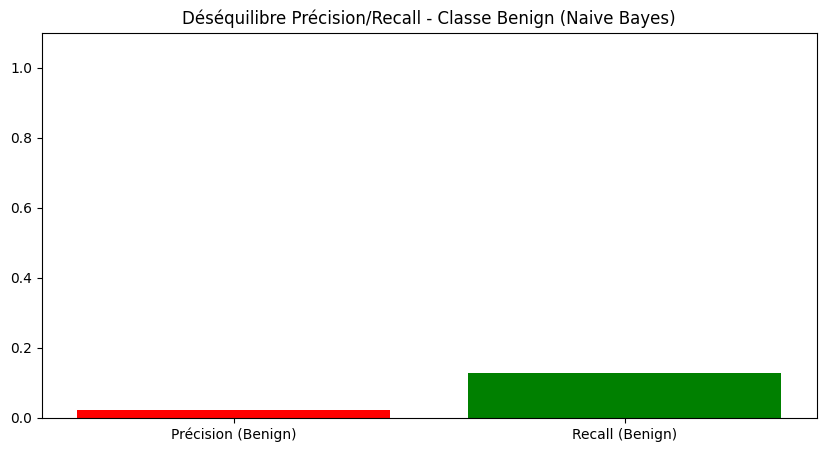

In [ ]:
# Déséquilibre Précision/Recall
precision_benign = metrics['Précision']['Benign']
recall_benign = metrics['Recall']['Benign']

plt.figure(figsize=(10, 5))
plt.bar(['Précision (Benign)', 'Recall (Benign)'],
        [precision_benign, recall_benign],
        color=['red', 'green'])
plt.ylim(0, 1.1)
plt.title('Déséquilibre Précision/Recall - Classe Benign (Naive Bayes)')
plt.savefig("Desequilibre-Precision-Recall-Benign_NB.png")
plt.show()


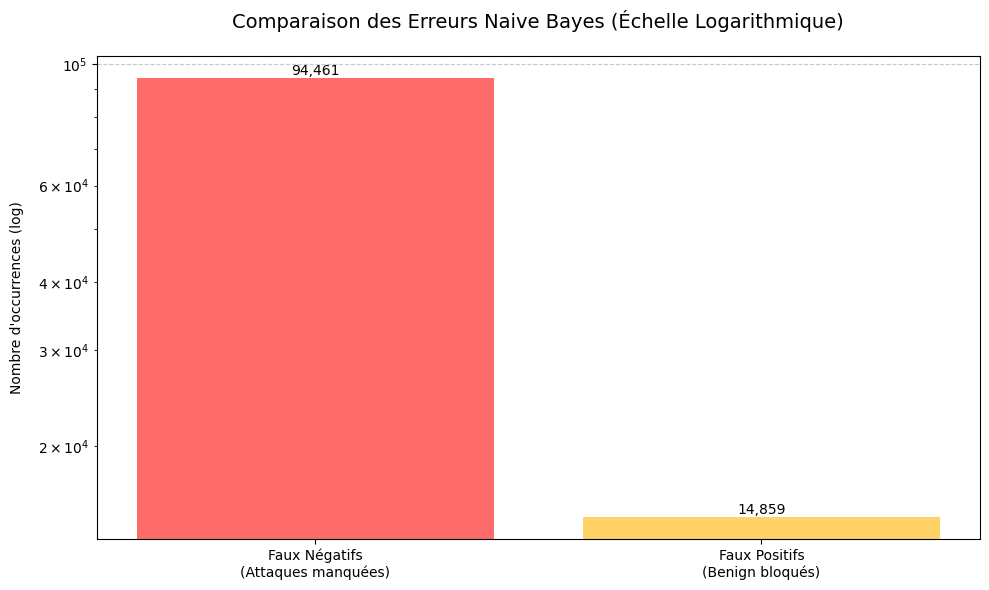

In [ ]:
# Comparaison des erreurs
values = [FN, FP]
labels = ['Faux Négatifs\n(Attaques manquées)', 'Faux Positifs\n(Benign bloqués)']
colors = ['#ff6b6b', '#ffd166']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, color=colors, log=True)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom')

ax.set_title('Comparaison des Erreurs Naive Bayes (Échelle Logarithmique)', pad=20, fontsize=14)
ax.set_ylabel("Nombre d'occurrences (log)", labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("FN-vs-FP_NB.png")
plt.show()

# KNN

In [18]:
# Sélection de 1 000 000 échantillons pour l'entraînement
X_train_adasyn_small, _, y_train_adasyn_small, _ = train_test_split(
    X_train_adasyn, y_train_adasyn,
    train_size=1_000_000,
    stratify=y_train_adasyn,
    random_state=42
)

In [ ]:
# Sélection de 500 000 échantillons pour le test
X_test_normalized_small, _, y_test_small, _ = train_test_split(
    X_test_normalized, y_test,
    train_size=500_000,
    stratify=y_test,
    random_state=42
)

In [ ]:
# --- 3. Entraînement sur données rééquilibrées ---
model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    algorithm='auto',
    leaf_size=30,
    p=2,  # Distance euclidienne
    metric='minkowski',
    n_jobs=-1
)

In [ ]:
import time

start_train = time.time()
model.fit(X_train_adasyn_small, y_train_adasyn_small)
end_train = time.time()

In [ ]:
import joblib
# Sauvegarde du modèle dans un fichier .pkl
joblib.dump(model, 'modelv3_knn_new.pkl')

import zipfile
# 3. Créer un fichier ZIP et y ajouter le .pkl
zip_filename = 'v3_KNN_model_new.zip'
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write('modelv3_knn_new.pkl')
print(f"Modèle sauvegardé et compressé avec succès dans : {zip_filename}")


Modèle sauvegardé et compressé avec succès dans : v3_KNN_model_new.zip


In [ ]:
# Prédiction avec mesure du temps
start_pred = time.time()
y_pred = model.predict(X_test_normalized_small)
y_pred_prob = model.predict_proba(X_test_normalized_small)[:, 1]
end_pred = time.time()

In [ ]:
# Création initiale du fichier avec un en-tête
with open("resultats_analyse_knn.txt", "w", encoding="utf-8") as f:
    f.write("═"*60 + "\n")
    f.write("           RAPPORT D'ÉVALUATION DU MODÈLE KNN           \n")
    f.write("═"*60 + "\n\n")

In [ ]:
# Évaluer
report = classification_report(y_test_small, y_pred)
matrix = confusion_matrix(y_test_small, y_pred)

# Affichage
print("Classification Report :\n", report)
print("Confusion Matrix :\n", matrix)

# Sauvegarde dans le fichier texte sans écrasement
with open("resultats_analyse_knn.txt", "a", encoding="utf-8") as f:
    f.write("=== RAPPORT DE CLASSIFICATION ===\n")
    f.write(report + "\n")
    f.write("=== MATRICE DE CONFUSION ===\n")
    f.write(np.array2string(matrix, separator=' ') + "\n\n")

Classification Report :
               precision    recall  f1-score   support

           0       0.52      0.99      0.69       584
           1       1.00      1.00      1.00    499416

    accuracy                           1.00    500000
   macro avg       0.76      1.00      0.84    500000
weighted avg       1.00      1.00      1.00    500000

Confusion Matrix :
 [[   580      4]
 [   527 498889]]


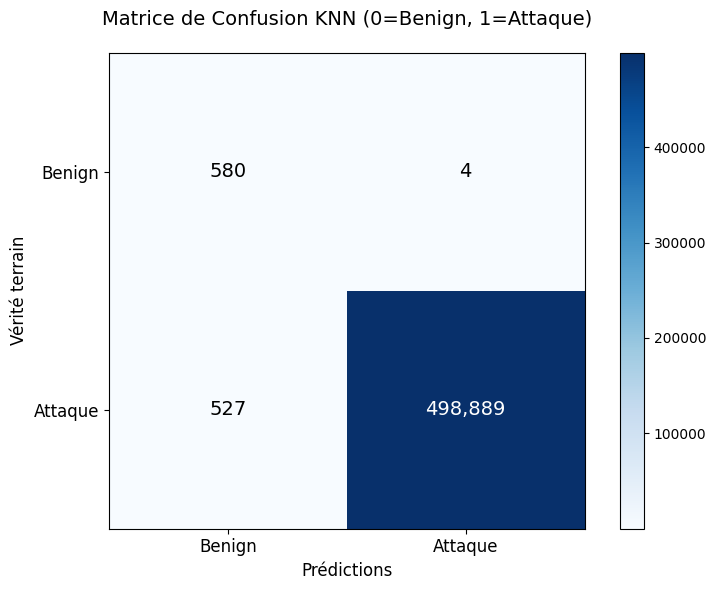

In [ ]:
# Matrice de confusion
cm = confusion_matrix(y_test_small, y_pred)

# Création d'une visualisation claire
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matrice de Confusion KNN (0=Benign, 1=Attaque)', fontsize=14, pad=20)
plt.colorbar()

# Configuration des axes
class_names = ['Benign', 'Attaque']
plt.xticks([0, 1], class_names, fontsize=12)
plt.yticks([0, 1], class_names, fontsize=12)
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Vérité terrain', fontsize=12)

# Ajout des valeurs annotées
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i, j]:,}",  # Format avec séparateurs de milliers
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=14)

# Affichage et sauvegarde
plt.tight_layout()
plt.savefig('matrice_confusion_KNN.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Calcul du FPR à partir de la matrice de confusion
TN, FP, FN, TP = cm.ravel()  # Récupère les valeurs de la matrice de confusion

FPR = FP / (FP + TN)  # Taux de faux positifs (FPR)
print(f""" - Taux de Faux Positifs (FPR) : {FPR:.4f}""")

FNR = FN / (FN + TP)
print(f""" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}
""")

# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse_knn.txt", "a", encoding="utf-8") as f:
    f.write(f" - Taux de Faux Positifs (FPR) : {FPR:.4f}\n")
    f.write(f" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}\n\n")

 - Taux de Faux Positifs (FPR) : 0.0068
 - Taux de Faux Négatifs (Attaques manquées) FNR: 0.0011



In [ ]:
# 8. Temps de prédiction et d'entrainement
print(f"Temps de prédiction : {end_pred - start_pred:.2f} secondes")
print(f"Temps d'entrainement : {end_train - start_train:.2f} secondes")
temps_prediction = end_pred - start_pred
temps_train = end_train - start_train

# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse_knn.txt", "a", encoding="utf-8") as f:
    f.write(f"Temps de prédiction : {temps_prediction:.2f} secondes\n\n")
    f.write(f"Temps d'entrainement  : {temps_train:.2f} secondes\n\n")


Temps de prédiction : 69.47 secondes
Temps d'entrainement : 4.05 secondes


In [ ]:
# Note: KNN n'a pas de feature importance comme les modèles basés sur les arbres
# On passe donc directement aux courbes d'apprentissage

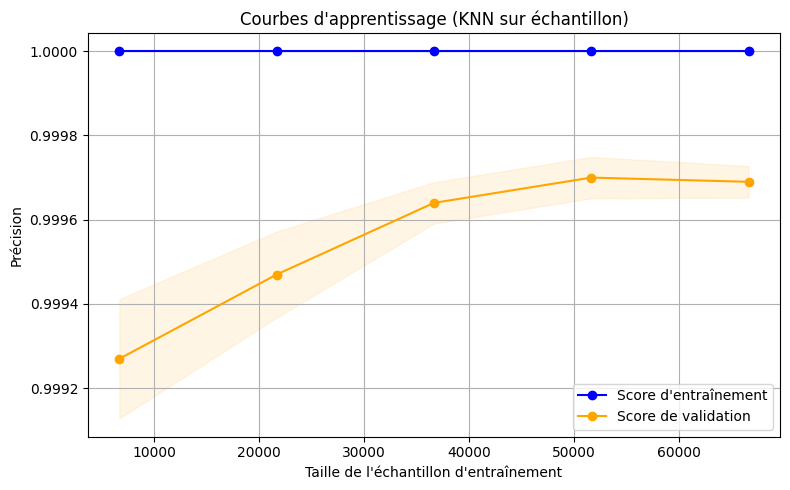

In [ ]:
# Courbes d'apprentissage (sur échantillon réduit)
X_sample, y_sample = resample(X_test_normalized_small, y_test_small,
                             n_samples=100000, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    model, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d'apprentissage (KNN sur échantillon)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_KNN.png")
plt.show()

In [19]:
import joblib
modelknn = joblib.load('modelv3_knn_new.pkl')
print(type(modelknn))

<class 'sklearn.neighbors._classification.KNeighborsClassifier'>


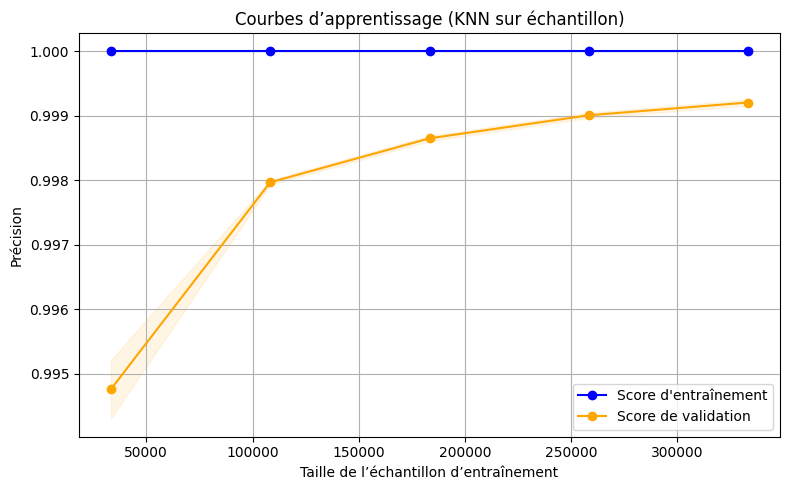

In [20]:

from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_train_adasyn_small, y_train_adasyn_small, n_samples=500000, random_state=42)

# Génération des courbes d’apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    modelknn, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d’apprentissage (KNN sur échantillon)")
plt.xlabel("Taille de l’échantillon d’entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_train_knn_v3.png")
plt.show()


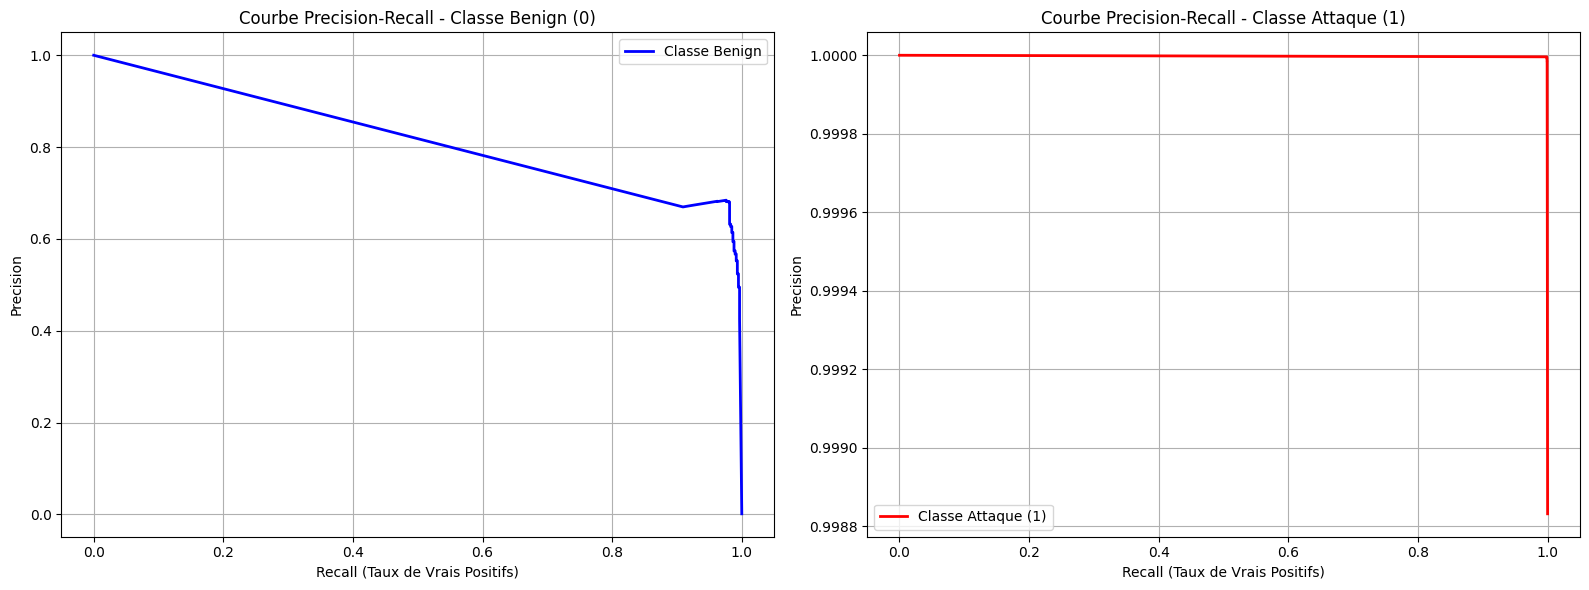

In [ ]:
# Courbes Precision-Recall
plt.figure(figsize=(16, 6))

# 1. Subplot GAUCHE - Classe Benign
plt.subplot(1, 2, 1)
precision_benign, recall_benign, _ = precision_recall_curve(y_test_small, 1 - y_pred_prob, pos_label=0)
plt.plot(recall_benign, precision_benign, color='blue', lw=2, label='Classe Benign')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - Classe Benign (0)')
plt.legend()
plt.grid()
plt.autoscale(enable=True, axis='both', tight=False)

# 2. Subplot DROITE - Classe Attaque
plt.subplot(1, 2, 2)
precision_attack, recall_attack, _ = precision_recall_curve(y_test_small, y_pred_prob, pos_label=1)
plt.plot(recall_attack, precision_attack, color='red', lw=2, label='Classe Attaque (1)')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - Classe Attaque (1)')
plt.legend()
plt.grid()
plt.autoscale(enable=True, axis='both', tight=False)

plt.tight_layout()
plt.savefig("courbes-precision-recall-0-1_KNN.png")
plt.show()


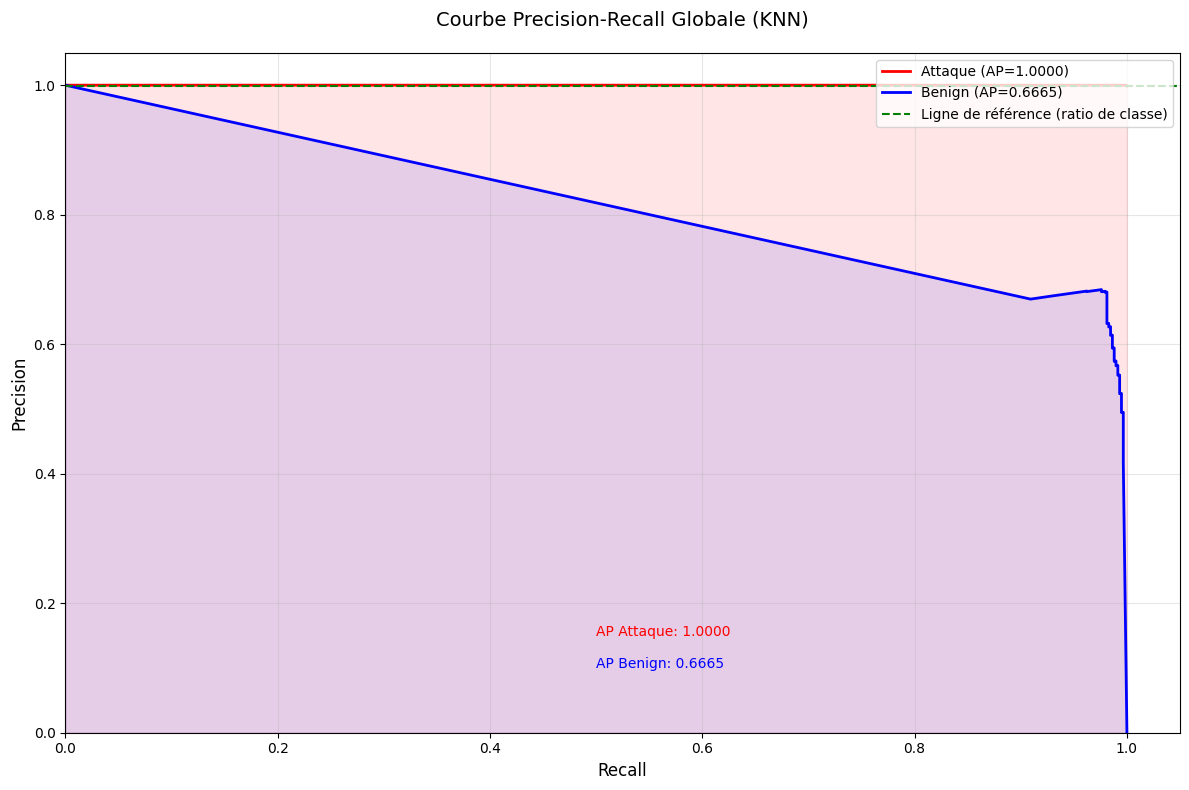

In [ ]:
# Courbe Precision-Recall globale
ap_attack = average_precision_score(y_test_small, y_pred_prob, pos_label=1)
ap_benign = average_precision_score(y_test_small, 1 - y_pred_prob, pos_label=0)

plt.figure(figsize=(12, 8))
plt.plot(recall_attack, precision_attack, color='red', lw=2,
         label=f'Attaque (AP={ap_attack:.4f})', linestyle='-')
plt.plot(recall_benign, precision_benign, color='blue', lw=2,
         label=f'Benign (AP={ap_benign:.4f})', linestyle='-')
plt.axhline(y=len(y_test_small[y_test_small==1])/len(y_test_small), color='green', linestyle='--',
            label='Ligne de référence (ratio de classe)')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Courbe Precision-Recall Globale (KNN)', fontsize=14, pad=20)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])

plt.text(0.5, 0.15, f"AP Attaque: {ap_attack:.4f}", color='red', fontsize=10)
plt.text(0.5, 0.10, f"AP Benign: {ap_benign:.4f}", color='blue', fontsize=10)

plt.fill_between(recall_attack, precision_attack, color='red', alpha=0.1)
plt.fill_between(recall_benign, precision_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-precision-recall-global_KNN.png")
plt.show()

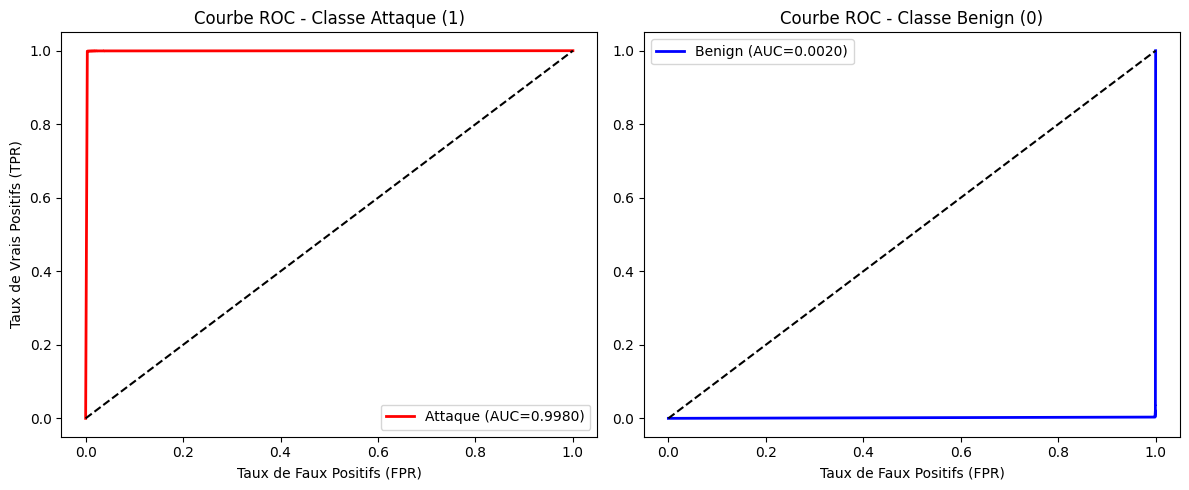

In [ ]:
# Courbes ROC
fpr_attack, tpr_attack, _ = roc_curve(y_test_small, y_pred_prob, pos_label=1)
auc_attack = roc_auc_score(y_test_small, y_pred_prob)

fpr_benign, tpr_benign, _ = roc_curve(y_test_small, y_pred_prob, pos_label=0)
auc_benign = roc_auc_score(y_test_small, 1 - y_pred_prob)

plt.figure(figsize=(12, 5))

# Subplot gauche - Attaque
plt.subplot(1, 2, 1)
plt.plot(fpr_attack, tpr_attack, color='red', lw=2, label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC - Classe Attaque (1)')
plt.legend()

# Subplot droit - Benign
plt.subplot(1, 2, 2)
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2, label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.title('Courbe ROC - Classe Benign (0)')
plt.legend()

plt.tight_layout()
plt.savefig("courbes-ROC-0-1_KNN.png")
plt.show()

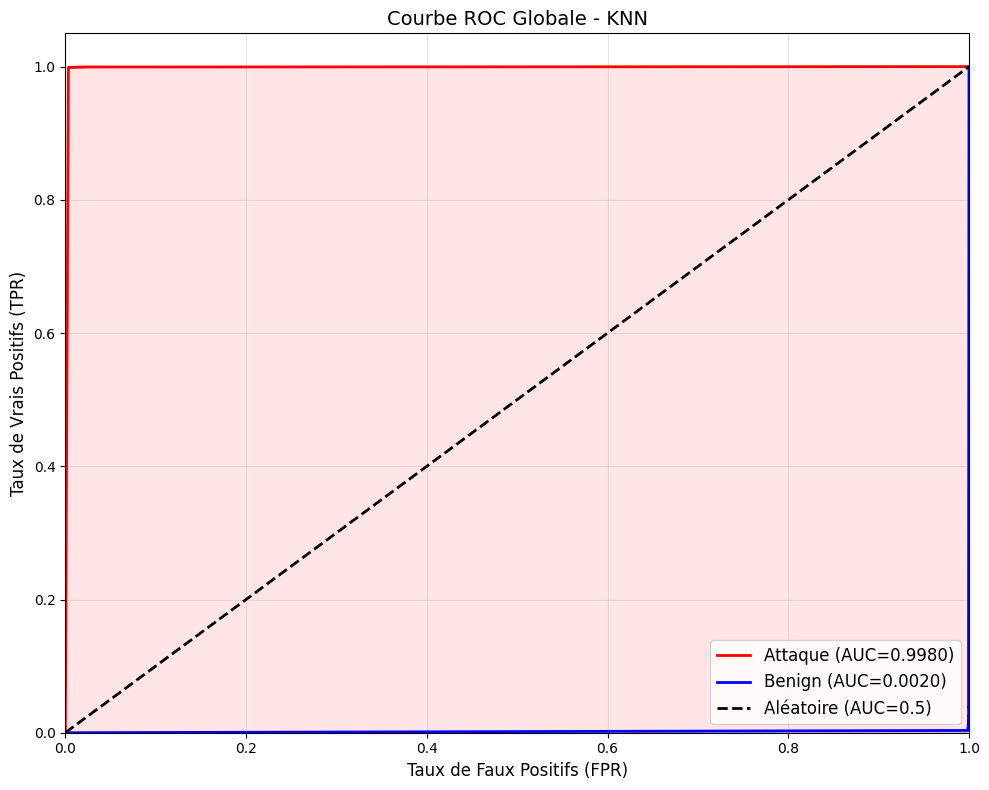

In [ ]:
# Courbe ROC globale
plt.figure(figsize=(10, 8))
plt.plot(fpr_attack, tpr_attack, color='red', lw=2,
         label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2,
         label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Aléatoire (AUC=0.5)')

plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC Globale - KNN', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.fill_between(fpr_attack, tpr_attack, color='red', alpha=0.1)
plt.fill_between(fpr_benign, tpr_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-ROC-globale_KNN.png")
plt.show()

In [ ]:
# Affichage des performances AUC-ROC
auc_global = (auc_attack + auc_benign) / 2

print("\n" + "═"*50)
print(" PERFORMANCE DU MODÈLE KNN ".center(50, "~"))
print("═"*50)
print(f"\n\033[1m• AUC-ROC Classe Attaque (1)\033[0m : {auc_attack:.6f}")
print(f"\033[1m• AUC-ROC Classe Benign (0)\033[0m  : {auc_benign:.6f}")
print(f"\n\033[1m• AUC-ROC Global (macro)\033[0m     : {auc_global:.6f}")
print("\n" + "═"*50)

with open("resultats_analyse_knn.txt", "a", encoding="utf-8") as f:
    f.write("\n" + "═"*50 + "\n")
    f.write(" PERFORMANCE DU MODÈLE KNN ".center(50, "~") + "\n")
    f.write("═"*50 + "\n")
    f.write(f"\n• AUC-ROC Classe Attaque (1) : {auc_attack:.6f}\n")
    f.write(f"• AUC-ROC Classe Benign (0)  : {auc_benign:.6f}\n")
    f.write(f"\n• AUC-ROC Global (macro)     : {auc_global:.6f}\n")
    f.write("═"*50 + "\n\n")


══════════════════════════════════════════════════
~~~~~~~~~~~ PERFORMANCE DU MODÈLE KNN ~~~~~~~~~~~~
══════════════════════════════════════════════════

• AUC-ROC Classe Attaque (1) : 0.997995
• AUC-ROC Classe Benign (0)  : 0.002005

• AUC-ROC Global (macro)     : 0.500000

══════════════════════════════════════════════════


In [ ]:
# Tableau récapitulatif des métriques
metrics = {
    'Précision': {
        'Benign': precision_score(y_test_small, y_pred, pos_label=0),
        'Attaque': precision_score(y_test_small, y_pred, pos_label=1),
        'Global': precision_score(y_test_small, y_pred, average='macro')
    },
    'Recall': {
        'Benign': recall_score(y_test_small, y_pred, pos_label=0),
        'Attaque': recall_score(y_test_small, y_pred, pos_label=1),
        'Global': recall_score(y_test_small, y_pred, average='macro')
    },
    'F1-Score': {
        'Benign': f1_score(y_test_small, y_pred, pos_label=0),
        'Attaque': f1_score(y_test_small, y_pred, pos_label=1),
        'Global': f1_score(y_test_small, y_pred, average='macro')
    },
    'Accuracy': {
        'Global': accuracy_score(y_test_small, y_pred)
    }
}

print("╔═════════════════════════════════════════════╗")
print("║          PERFORMANCE DU MODÈLE KNN          ║")
print("╠══════════════╦══════════╦══════════╦════════╣")
print("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║")
print("╠══════════════╬══════════╬══════════╬════════╣")

for metric_name, values in metrics.items():
    if metric_name == 'Accuracy':
        print(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║")
    else:
        print(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║")

print("╚══════════════╩══════════╩══════════╩════════╝")

with open("resultats_analyse_knn.txt", "a", encoding="utf-8") as f:
    f.write("╔═════════════════════════════════════════════╗\n")
    f.write("║          PERFORMANCE DU MODÈLE KNN          ║\n")
    f.write("╠══════════════╦══════════╦══════════╦════════╣\n")
    f.write("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║\n")
    f.write("╠══════════════╬══════════╬══════════╬════════╣\n")

    for metric_name, values in metrics.items():
        if metric_name == 'Accuracy':
            f.write(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║\n")
        else:
            f.write(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║\n")

    f.write("╚══════════════╩══════════╩══════════╩════════╝\n\n")

╔═════════════════════════════════════════════╗
║          PERFORMANCE DU MODÈLE KNN          ║
╠══════════════╦══════════╦══════════╦════════╣
║   Métrique   ║  Benign  ║ Attaque  ║ Global ║
╠══════════════╬══════════╬══════════╬════════╣
║ Précision    ║ 0.5239   ║ 1.0000   ║ 0.7620 ║
║ Recall       ║ 0.9932   ║ 0.9989   ║ 0.9960 ║
║ F1-Score     ║ 0.6860   ║ 0.9995   ║ 0.8427 ║
║ Accuracy     ║          ║          ║ 0.9989 ║
╚══════════════╩══════════╩══════════╩════════╝


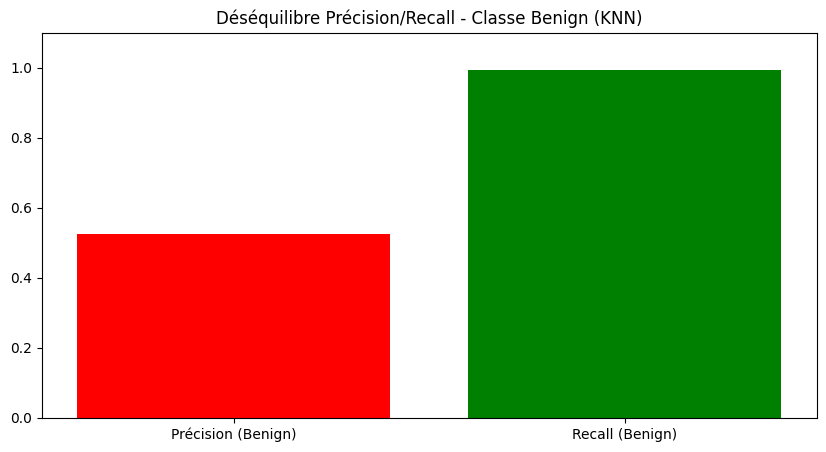

In [ ]:
# Déséquilibre Précision/Recall
precision_benign = metrics['Précision']['Benign']
recall_benign = metrics['Recall']['Benign']

plt.figure(figsize=(10, 5))
plt.bar(['Précision (Benign)', 'Recall (Benign)'],
        [precision_benign, recall_benign],
        color=['red', 'green'])
plt.ylim(0, 1.1)
plt.title('Déséquilibre Précision/Recall - Classe Benign (KNN)')
plt.savefig("Desequilibre-Precision-Recall-Benign_KNN.png")
plt.show()

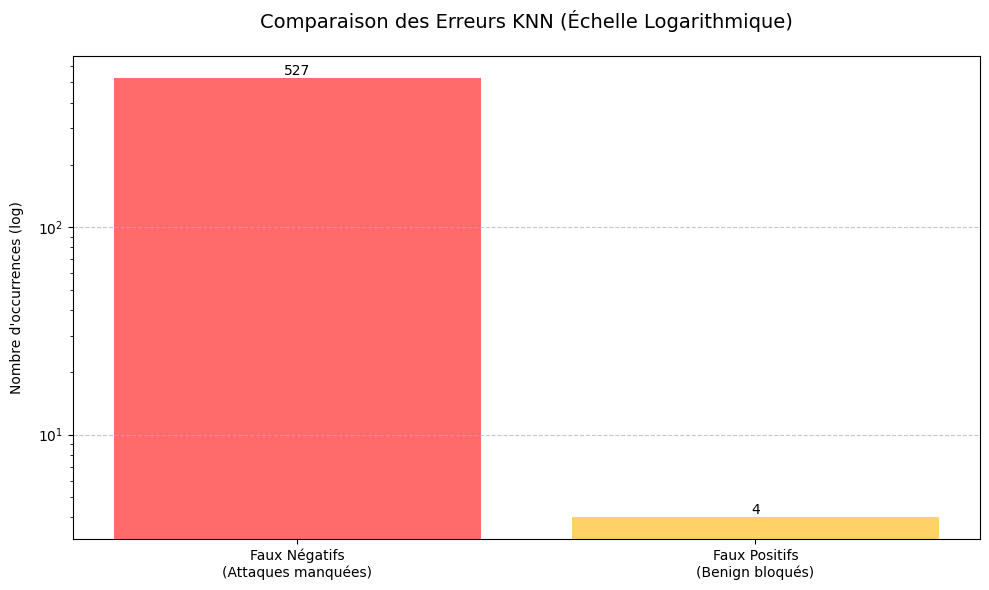

In [ ]:
# Comparaison des erreurs
values = [FN, FP]
labels = ['Faux Négatifs\n(Attaques manquées)', 'Faux Positifs\n(Benign bloqués)']
colors = ['#ff6b6b', '#ffd166']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, color=colors, log=True)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom')

ax.set_title('Comparaison des Erreurs KNN (Échelle Logarithmique)', pad=20, fontsize=14)
ax.set_ylabel("Nombre d'occurrences (log)", labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("FN-vs-FP_KNN.png")
plt.show()

# SVM LinearSVC

In [ ]:
# Sélection de 1 000 000 échantillons pour l'entraînement
#X_train_adasyn_small, _, y_train_adasyn_small, _ = train_test_split(
#    X_train_adasyn, y_train_adasyn,
#    train_size=1_000_000,
#    stratify=y_train_adasyn,
#    random_state=42
#)
# Sélection de 500 000 échantillons pour le test
#X_test_normalized_small, _, y_test_small, _ = train_test_split(
#    X_test_normalized, y_test,
#    train_size=500_000,
#    stratify=y_test,
#    random_state=42
#)


In [ ]:
# --- 3. Entraînement sur données rééquilibrées ---
from sklearn.svm import LinearSVC
model = LinearSVC(
    C=1.0,
    class_weight='balanced',  # Pour gérer le déséquilibre de classe
    random_state=42,
    max_iter=1000,
    dual=False,  # Préférable quand n_samples > n_features
    verbose=1
)

In [ ]:
import time

start_train = time.time()
model.fit(X_train_adasyn_small, y_train_adasyn_small)
end_train = time.time()

[LibLinear]

In [ ]:
import joblib
# Sauvegarde du modèle dans un fichier .pkl
joblib.dump(model, 'modelv3_linearsvc_new.pkl')

import zipfile
# 3. Créer un fichier ZIP et y ajouter le .pkl
zip_filename = 'v3_LinearSVC_model_new.zip'
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write('modelv3_linearsvc_new.pkl')
print(f"Modèle sauvegardé et compressé avec succès dans : {zip_filename}")

Modèle sauvegardé et compressé avec succès dans : v3_LinearSVC_model_new.zip


In [ ]:
# Prédiction avec mesure du temps
start_pred = time.time()
y_pred = model.predict(X_test_normalized_small)
# Pour LinearSVC, nous devons utiliser decision_function pour les probabilités
decision_scores = model.decision_function(X_test_normalized_small)
# Conversion des scores de décision en probabilités avec sigmoid
from scipy.special import expit
y_pred_prob = expit(decision_scores)
end_pred = time.time()

In [ ]:
# Création initiale du fichier avec un en-tête
with open("resultats_analyse_linearsvc.txt", "w", encoding="utf-8") as f:
    f.write("═"*60 + "\n")
    f.write("           RAPPORT D'ÉVALUATION DU MODÈLE LinearSVC           \n")
    f.write("═"*60 + "\n\n")

In [ ]:
# Évaluer
report = classification_report(y_test_small, y_pred)
matrix = confusion_matrix(y_test_small, y_pred)

# Affichage
print("Classification Report :\n", report)
print("Confusion Matrix :\n", matrix)

# Sauvegarde dans le fichier texte sans écrasement
with open("resultats_analyse_linearsvc.txt", "a", encoding="utf-8") as f:
    f.write("=== RAPPORT DE CLASSIFICATION ===\n")
    f.write(report + "\n")
    f.write("=== MATRICE DE CONFUSION ===\n")
    f.write(np.array2string(matrix, separator=' ') + "\n\n")


Classification Report :
               precision    recall  f1-score   support

           0       0.01      0.88      0.01       584
           1       1.00      0.82      0.90    499416

    accuracy                           0.82    500000
   macro avg       0.50      0.85      0.46    500000
weighted avg       1.00      0.82      0.90    500000

Confusion Matrix :
 [[   516     68]
 [ 90558 408858]]


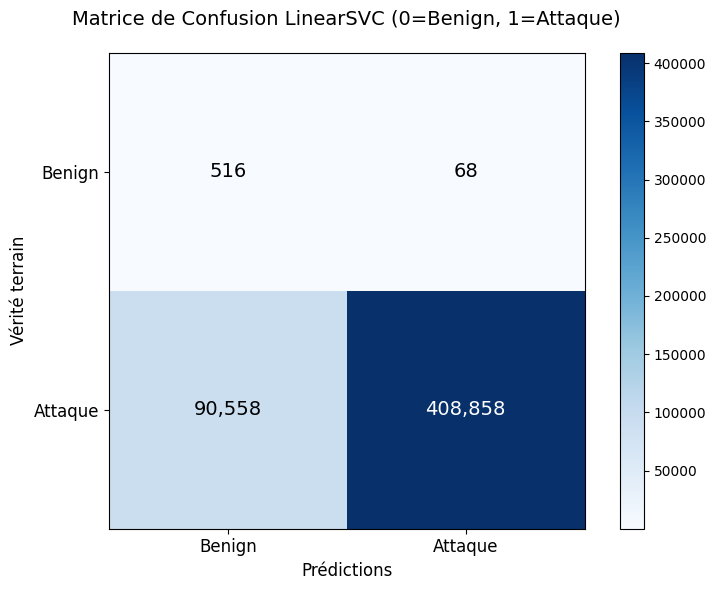

In [ ]:
# Matrice de confusion
cm = confusion_matrix(y_test_small, y_pred)

# Création d'une visualisation claire
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matrice de Confusion LinearSVC (0=Benign, 1=Attaque)', fontsize=14, pad=20)
plt.colorbar()

# Configuration des axes
class_names = ['Benign', 'Attaque']
plt.xticks([0, 1], class_names, fontsize=12)
plt.yticks([0, 1], class_names, fontsize=12)
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Vérité terrain', fontsize=12)

# Ajout des valeurs annotées
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i, j]:,}",  # Format avec séparateurs de milliers
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=14)

# Affichage et sauvegarde
plt.tight_layout()
plt.savefig('matrice_confusion_LinearSVC.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Calcul du FPR à partir de la matrice de confusion
TN, FP, FN, TP = cm.ravel()  # Récupère les valeurs de la matrice de confusion

FPR = FP / (FP + TN)  # Taux de faux positifs (FPR)
print(f""" - Taux de Faux Positifs (FPR) : {FPR:.4f}""")

FNR = FN / (FN + TP)
print(f""" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}
""")

# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse_linearsvc.txt", "a", encoding="utf-8") as f:
    f.write(f" - Taux de Faux Positifs (FPR) : {FPR:.4f}\n")
    f.write(f" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}\n\n")


 - Taux de Faux Positifs (FPR) : 0.1164
 - Taux de Faux Négatifs (Attaques manquées) FNR: 0.1813



In [ ]:
# 8. Temps de prédiction et d'entrainement
print(f"Temps de prédiction : {end_pred - start_pred:.2f} secondes")
print(f"Temps d'entrainement : {end_train - start_train:.2f} secondes")
temps_prediction = end_pred - start_pred
temps_train = end_train - start_train

# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse_linearsvc.txt", "a", encoding="utf-8") as f:
    f.write(f"Temps de prédiction : {temps_prediction:.2f} secondes\n\n")
    f.write(f"Temps d'entrainement  : {temps_train:.2f} secondes\n\n")


Temps de prédiction : 0.36 secondes
Temps d'entrainement : 17.96 secondes


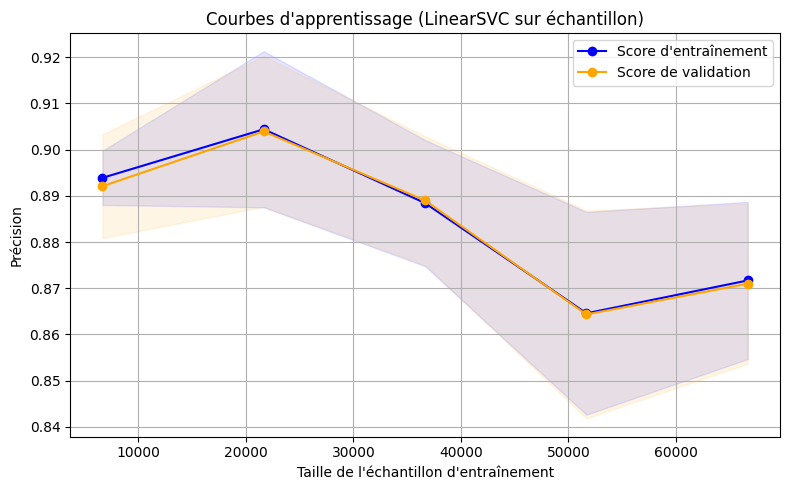

In [ ]:
# Courbes d'apprentissage (sur échantillon réduit)
X_sample, y_sample = resample(X_test_normalized_small, y_test_small,
                             n_samples=100000, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    model, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d'apprentissage (LinearSVC sur échantillon)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_LinearSVC.png")
plt.show()


In [16]:
import joblib
modelsvm = joblib.load('modelv3_linearsvc_new.pkl')
print(type(modelsvm))


<class 'sklearn.svm._classes.LinearSVC'>


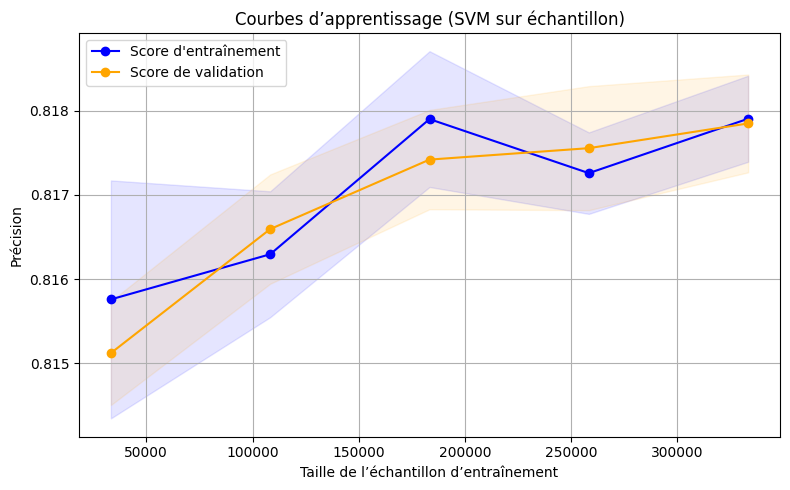

In [17]:

from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_train_adasyn, y_train_adasyn, n_samples=500000, random_state=42)

# Génération des courbes d’apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    modelsvm, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d’apprentissage (SVM sur échantillon)")
plt.xlabel("Taille de l’échantillon d’entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_train_svm_v3.png")
plt.show()


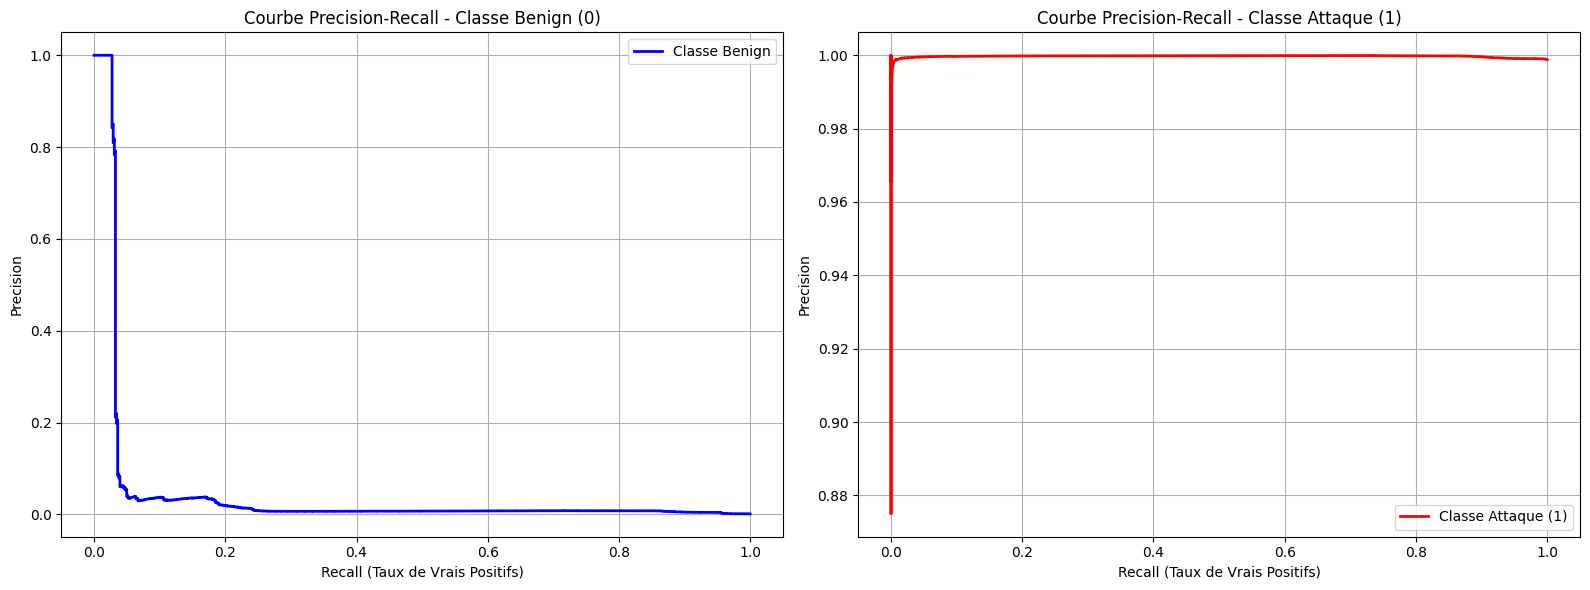

In [ ]:
# Courbes Precision-Recall
plt.figure(figsize=(16, 6))

# 1. Subplot GAUCHE - Classe Benign
plt.subplot(1, 2, 1)
precision_benign, recall_benign, _ = precision_recall_curve(y_test_small, -decision_scores, pos_label=0)
plt.plot(recall_benign, precision_benign, color='blue', lw=2, label='Classe Benign')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - Classe Benign (0)')
plt.legend()
plt.grid()
plt.autoscale(enable=True, axis='both', tight=False)

# 2. Subplot DROITE - Classe Attaque
plt.subplot(1, 2, 2)
precision_attack, recall_attack, _ = precision_recall_curve(y_test_small, decision_scores, pos_label=1)
plt.plot(recall_attack, precision_attack, color='red', lw=2, label='Classe Attaque (1)')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - Classe Attaque (1)')
plt.legend()
plt.grid()
plt.autoscale(enable=True, axis='both', tight=False)

plt.tight_layout()
plt.savefig("courbes-precision-recall-0-1_LinearSVC.png")
plt.show()

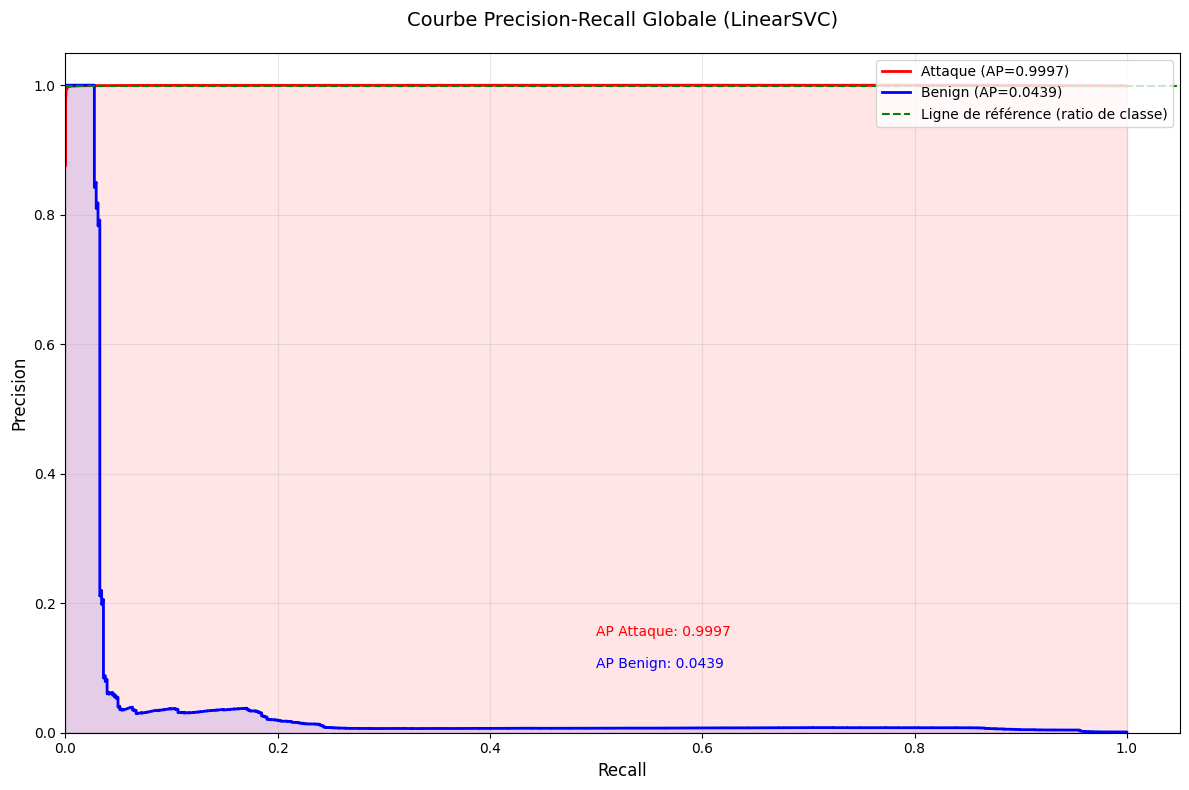

In [ ]:
# Courbe Precision-Recall globale
ap_attack = average_precision_score(y_test_small, decision_scores, pos_label=1)
ap_benign = average_precision_score(y_test_small, -decision_scores, pos_label=0)

plt.figure(figsize=(12, 8))
plt.plot(recall_attack, precision_attack, color='red', lw=2,
         label=f'Attaque (AP={ap_attack:.4f})', linestyle='-')
plt.plot(recall_benign, precision_benign, color='blue', lw=2,
         label=f'Benign (AP={ap_benign:.4f})', linestyle='-')
plt.axhline(y=len(y_test_small[y_test_small==1])/len(y_test_small), color='green', linestyle='--',
            label='Ligne de référence (ratio de classe)')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Courbe Precision-Recall Globale (LinearSVC)', fontsize=14, pad=20)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])

plt.text(0.5, 0.15, f"AP Attaque: {ap_attack:.4f}", color='red', fontsize=10)
plt.text(0.5, 0.10, f"AP Benign: {ap_benign:.4f}", color='blue', fontsize=10)

plt.fill_between(recall_attack, precision_attack, color='red', alpha=0.1)
plt.fill_between(recall_benign, precision_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-precision-recall-global_LinearSVC.png")
plt.show()

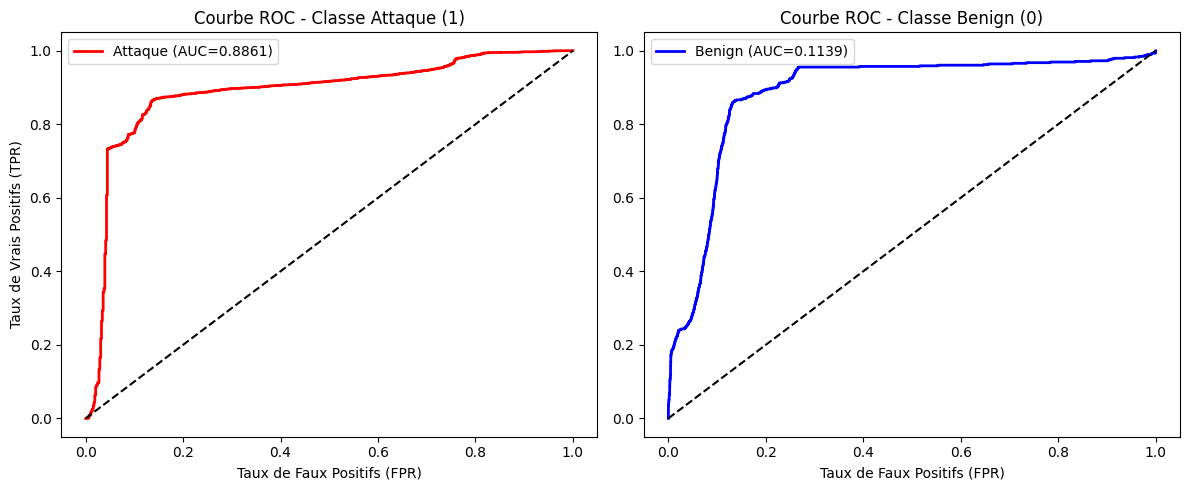

In [ ]:
# Courbes ROC
fpr_attack, tpr_attack, _ = roc_curve(y_test_small, decision_scores, pos_label=1)
auc_attack = roc_auc_score(y_test_small, decision_scores)

fpr_benign, tpr_benign, _ = roc_curve(y_test_small, -decision_scores, pos_label=0)
auc_benign = roc_auc_score(y_test_small, -decision_scores)

plt.figure(figsize=(12, 5))

# Subplot gauche - Attaque
plt.subplot(1, 2, 1)
plt.plot(fpr_attack, tpr_attack, color='red', lw=2, label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC - Classe Attaque (1)')
plt.legend()

# Subplot droit - Benign
plt.subplot(1, 2, 2)
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2, label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.title('Courbe ROC - Classe Benign (0)')
plt.legend()

plt.tight_layout()
plt.savefig("courbes-ROC-0-1_LinearSVC.png")
plt.show()

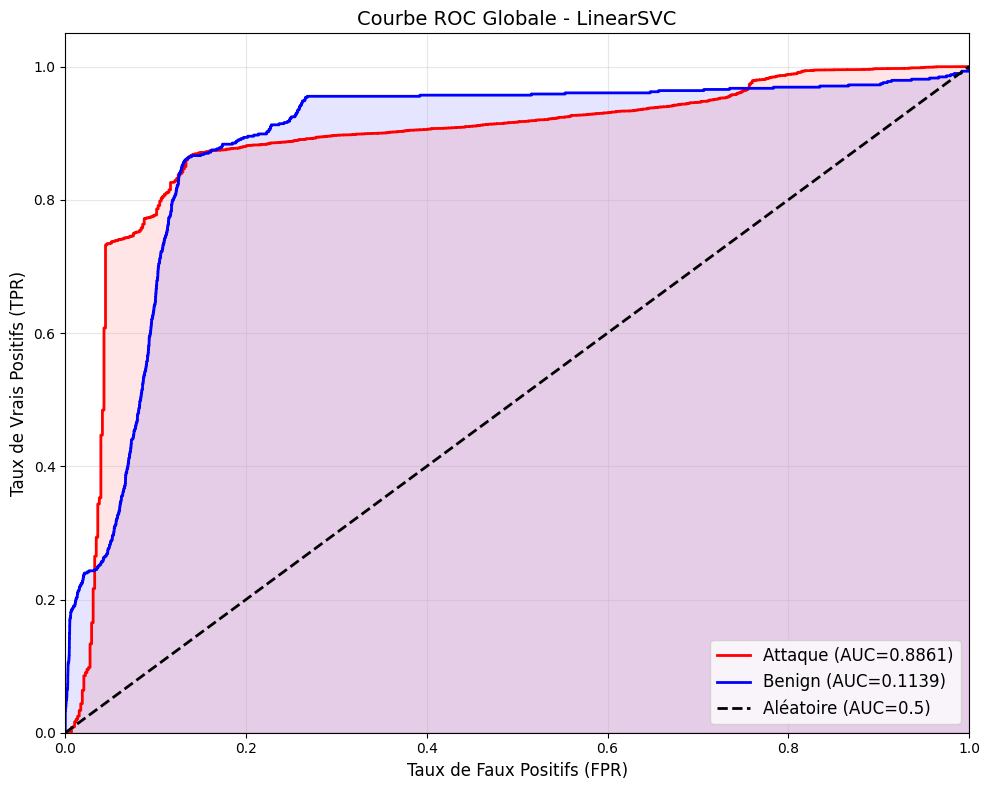

In [ ]:
# Courbe ROC globale
plt.figure(figsize=(10, 8))
plt.plot(fpr_attack, tpr_attack, color='red', lw=2,
         label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2,
         label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Aléatoire (AUC=0.5)')

plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC Globale - LinearSVC', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.fill_between(fpr_attack, tpr_attack, color='red', alpha=0.1)
plt.fill_between(fpr_benign, tpr_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-ROC-globale_LinearSVC.png")
plt.show()

In [ ]:
# Affichage des performances AUC-ROC
auc_global = (auc_attack + auc_benign) / 2

print("\n" + "═"*50)
print(" PERFORMANCE DU MODÈLE LinearSVC ".center(50, "~"))
print("═"*50)
print(f"\n\033[1m• AUC-ROC Classe Attaque (1)\033[0m : {auc_attack:.6f}")
print(f"\033[1m• AUC-ROC Classe Benign (0)\033[0m  : {auc_benign:.6f}")
print(f"\n\033[1m• AUC-ROC Global (macro)\033[0m     : {auc_global:.6f}")
print("\n" + "═"*50)

with open("resultats_analyse_linearsvc.txt", "a", encoding="utf-8") as f:
    f.write("\n" + "═"*50 + "\n")
    f.write(" PERFORMANCE DU MODÈLE LinearSVC ".center(50, "~") + "\n")
    f.write("═"*50 + "\n")
    f.write(f"\n• AUC-ROC Classe Attaque (1) : {auc_attack:.6f}\n")
    f.write(f"• AUC-ROC Classe Benign (0)  : {auc_benign:.6f}\n")
    f.write(f"\n• AUC-ROC Global (macro)     : {auc_global:.6f}\n")
    f.write("═"*50 + "\n\n")


══════════════════════════════════════════════════
~~~~~~~~ PERFORMANCE DU MODÈLE LinearSVC ~~~~~~~~~
══════════════════════════════════════════════════

• AUC-ROC Classe Attaque (1) : 0.886068
• AUC-ROC Classe Benign (0)  : 0.113932

• AUC-ROC Global (macro)     : 0.500000

══════════════════════════════════════════════════


In [ ]:
# Tableau récapitulatif des métriques
metrics = {
    'Précision': {
        'Benign': precision_score(y_test_small, y_pred, pos_label=0),
        'Attaque': precision_score(y_test_small, y_pred, pos_label=1),
        'Global': precision_score(y_test_small, y_pred, average='macro')
    },
    'Recall': {
        'Benign': recall_score(y_test_small, y_pred, pos_label=0),
        'Attaque': recall_score(y_test_small, y_pred, pos_label=1),
        'Global': recall_score(y_test_small, y_pred, average='macro')
    },
    'F1-Score': {
        'Benign': f1_score(y_test_small, y_pred, pos_label=0),
        'Attaque': f1_score(y_test_small, y_pred, pos_label=1),
        'Global': f1_score(y_test_small, y_pred, average='macro')
    },
    'Accuracy': {
        'Global': accuracy_score(y_test_small, y_pred)
    }
}

print("╔═════════════════════════════════════════════╗")
print("║          PERFORMANCE DU MODÈLE LinearSVC    ║")
print("╠══════════════╦══════════╦══════════╦════════╣")
print("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║")
print("╠══════════════╬══════════╬══════════╬════════╣")

for metric_name, values in metrics.items():
    if metric_name == 'Accuracy':
        print(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║")
    else:
        print(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║")

print("╚══════════════╩══════════╩══════════╩════════╝")

with open("resultats_analyse_linearsvc.txt", "a", encoding="utf-8") as f:
    f.write("╔═════════════════════════════════════════════╗\n")
    f.write("║          PERFORMANCE DU MODÈLE LinearSVC    ║\n")
    f.write("╠══════════════╦══════════╦══════════╦════════╣\n")
    f.write("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║\n")
    f.write("╠══════════════╬══════════╬══════════╬════════╣\n")

    for metric_name, values in metrics.items():
        if metric_name == 'Accuracy':
            f.write(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║\n")
        else:
            f.write(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║\n")

    f.write("╚══════════════╩══════════╩══════════╩════════╝\n\n")


╔═════════════════════════════════════════════╗
║          PERFORMANCE DU MODÈLE LinearSVC    ║
╠══════════════╦══════════╦══════════╦════════╣
║   Métrique   ║  Benign  ║ Attaque  ║ Global ║
╠══════════════╬══════════╬══════════╬════════╣
║ Précision    ║ 0.0057   ║ 0.9998   ║ 0.5027 ║
║ Recall       ║ 0.8836   ║ 0.8187   ║ 0.8511 ║
║ F1-Score     ║ 0.0113   ║ 0.9002   ║ 0.4557 ║
║ Accuracy     ║          ║          ║ 0.8187 ║
╚══════════════╩══════════╩══════════╩════════╝


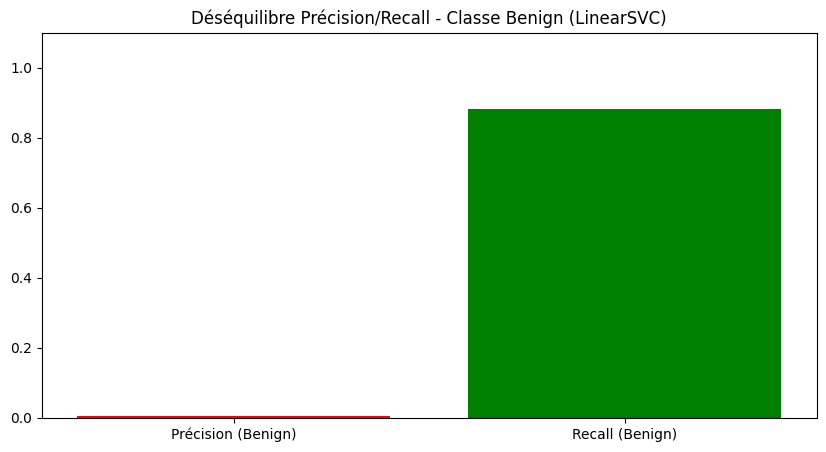

In [ ]:
# Déséquilibre Précision/Recall
precision_benign = metrics['Précision']['Benign']
recall_benign = metrics['Recall']['Benign']

plt.figure(figsize=(10, 5))
plt.bar(['Précision (Benign)', 'Recall (Benign)'],
        [precision_benign, recall_benign],
        color=['red', 'green'])
plt.ylim(0, 1.1)
plt.title('Déséquilibre Précision/Recall - Classe Benign (LinearSVC)')
plt.savefig("Desequilibre-Precision-Recall-Benign_LinearSVC.png")
plt.show()

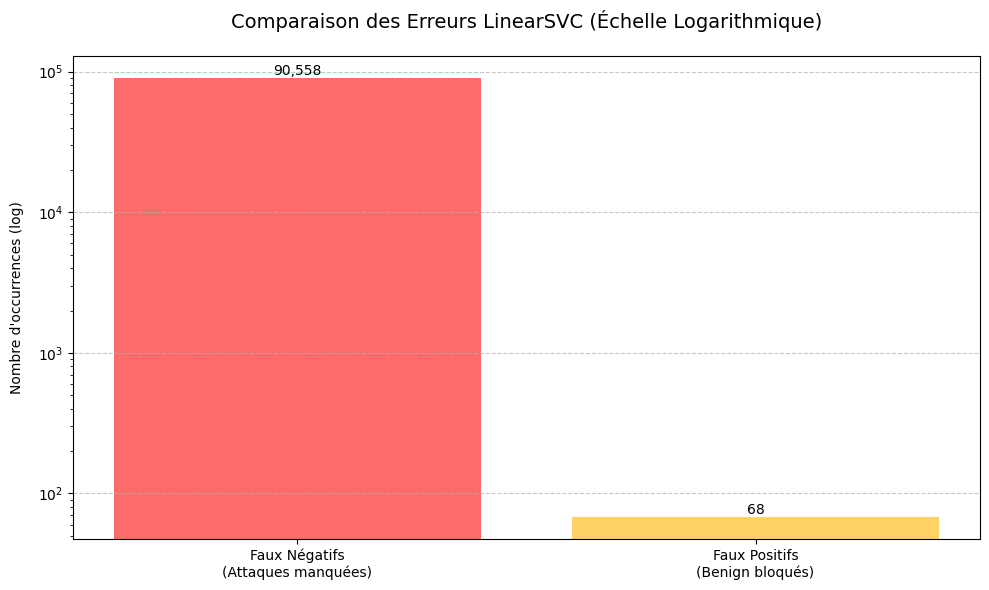

In [ ]:
# Comparaison des erreurs
values = [FN, FP]
labels = ['Faux Négatifs\n(Attaques manquées)', 'Faux Positifs\n(Benign bloqués)']
colors = ['#ff6b6b', '#ffd166']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, color=colors, log=True)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom')

ax.set_title('Comparaison des Erreurs LinearSVC (Échelle Logarithmique)', pad=20, fontsize=14)
ax.set_ylabel("Nombre d'occurrences (log)", labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("FN-vs-FP_LinearSVC.png")
plt.show()